# Evaluation of Physics Informed Nerual Networks (PINNs) for Solving Partial Differential Equations (PDEs)

## 0. Coding Enviornment Setup

In [1]:
# cell 0: deterministic workspace layout so cuda matrix operations produce reproducible results across runs
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

In [2]:
# cell 1: requied imports
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.sparse import diags, kron, identity
from scipy.sparse.linalg import spsolve
from scipy.stats.qmc import LatinHypercube
import torch
import torch.nn as nn
import torch.nn.functional as nnf
from tqdm import tqdm
import psutil
import warnings
import pandas as pd
import time
import tracemalloc
from itertools import product
import math
import random
import seaborn as sns
import glob
from pathlib import Path
from ipywidgets import interact, FloatSlider
import re
import copy

warnings.filterwarnings('ignore')
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [3]:
# cell 2: random seed and gpu establishment
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

os.environ['CUDA_VISIBLE_DEVICES'] = '0'
torch.cuda.set_device(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_tensor_type('torch.cuda.FloatTensor')

print(f"gpu: {torch.cuda.is_available()}")
print(f"device: {device}")
print(f"gpu name: {torch.cuda.get_device_name(0)}")

gpu: True
device: cuda
gpu name: Tesla P100-PCIE-16GB


## 1. White Gaussian Noise Setup

In [4]:
# cell 3: frozen noise protocol
def generate_frozen_noise(n_time_steps, noise_level, seed=seed):
    # generate a fixed noise trajectory for boundary conditions
    if noise_level == 0.0:
        return np.zeros(n_time_steps)
    
    # use distinct generator for noise isolation from global state
    rng = np.random.RandomState(seed)
    
    # generate white gaussian noise: N(0, noise_level)
    noise_vector = rng.normal(loc=0.0, scale=noise_level, size=n_time_steps)
    return noise_vector

print("frozen noise protocol defined successfully!")

frozen noise protocol defined successfully!


## 2. Directory Setup

In [5]:
# cell 4: define input and output directories
input_dir = '/kaggle/input/computed-solutions'
output_dir = 'project_outputs'
os.makedirs(output_dir, exist_ok=True)

## 3. Resumption Mechanism Setup

In [6]:
# cell 5: csv validation and flag setup
# expected csv file details
csv_details = {
    'analytical_solutions_1d.csv': {
        'columns': ['time', 'x', 'temperature'],
        'expected_rows': 900, # 60 eval_times * Nx
        'expected_cols': 3,
        'numeric_cols': ['time', 'x', 'temperature']
    },
    'analytical_solutions_2d.csv': {
        'columns': ['time', 'x', 'y', 'temperature'],
        'expected_rows': 13500, # 60 eval_times * Nx * Ny
        'expected_cols': 4,
        'numeric_cols': ['time', 'x', 'y', 'temperature']
    },
    'analytical_solutions_3d.csv': {
        'columns': ['time', 'x', 'y', 'z', 'temperature'],
        'expected_rows': 202500, # 60 eval_times * Nx * Ny * Nz
        'expected_cols': 5,
        'numeric_cols': ['time', 'x', 'y', 'z', 'temperature']
    },
    'fdm_solutions_1d.csv': {
        'columns': ['time', 'method', 'x', 'temperature'],
        'expected_rows': 2700, # 60 eval_times * Nx * 3 methods
        'expected_cols': 4,
        'numeric_cols': ['time', 'x', 'temperature'],
        'string_cols': ['method']
    },
    'fdm_solutions_2d.csv': {
        'columns': ['time', 'method', 'x', 'y', 'temperature'],
        'expected_rows': 40500, # 60 eval_times * Nx * Ny * 3 methods
        'expected_cols': 5,
        'numeric_cols': ['time', 'x', 'y', 'temperature'],
        'string_cols': ['method']
    },
    'fdm_solutions_3d.csv': {
        'columns': ['time', 'method', 'x', 'y', 'z', 'temperature'],
        'expected_rows': 607500, # 60 eval_times * Nx * Ny * Nz * 3 methods
        'expected_cols': 6,
        'numeric_cols': ['time', 'x', 'y', 'z', 'temperature'],
        'string_cols': ['method']
    },
    'fdm_benchmarks.csv': {
        'columns': ['dimension', 'method', 'execution_time_s', 'memory_usage_MB'],
        'expected_rows': 9, # 3 dimensions * 3 methods
        'expected_cols': 4,
        'numeric_cols': ['execution_time_s', 'memory_usage_MB'],
        'string_cols': ['dimension', 'method']
    },
    'pinn_tuning_results.csv': {
        'columns': [
            'depth', 'width', 'activation', 'learning_rate', 'dimension',
            'optimizer', 'switch_epoch_ratio', 'initialization', 'loss_weighting',
            'input_normalization', 'N_pde', 'N_bc', 'N_ic',
            'train_time', 'total_memory', 'l2_error', 'linf_error', 'rel_l2_error'
        ],
        'expected_cols': 18,
        'numeric_cols': ['depth', 'width', 'learning_rate', 'switch_epoch_ratio',
                         'N_pde', 'N_bc', 'N_ic', 'train_time', 'total_memory',
                         'l2_error', 'linf_error', 'rel_l2_error'],
        'string_cols': ['activation', 'dimension', 'optimizer', 'initialization', 'loss_weighting']
    }
}

In [7]:
# cell 6: validate each file path and expected details
def validate_csv(file_path, expected_details):
    # validate a csv file for existence, non-empty status, correct columns, shape, and data integrity
    try:
        # check file existence and non-empty status
        if not os.path.exists(file_path) or os.path.getsize(file_path) == 0:
            warnings.warn(f"file {file_path} does not exist or is empty")
            return False, None

        # read csv with minimal memory usage
        df = pd.read_csv(file_path, low_memory=False)

        # check for non-empty data
        if df.empty:
            warnings.warn(f"file {file_path} is empty")
            return False, None

        # validate columns
        expected_columns = expected_details['columns']
        if not all(col in df.columns for col in expected_columns) or len(df.columns) != expected_details['expected_cols']:
            warnings.warn(f"file {file_path} has incorrect columns. expected: {expected_columns}")
            return False, None

        # special handling for pinn_tuning_results.csv (extract tasks early)
        completed_tasks = None
        if os.path.basename(file_path) == 'pinn_tuning_results.csv':
            task_columns = ['depth', 'width', 'activation', 'learning_rate', 'dimension',
                            'optimizer', 'switch_epoch_ratio', 'initialization',
                            'loss_weighting', 'input_normalization']
            # drop rows missing any task-column before parsing
            df_tasks = df[task_columns].dropna(subset=task_columns, how='any').copy()
            completed_tasks = set()
            for _, row in df_tasks.iterrows():
                try:
                    task_tuple = (
                        int(row['depth']),
                        int(row['width']),
                        str(row['activation']),
                        float(row['learning_rate']),
                        str(row['dimension']),
                        str(row['optimizer']),
                        float(row['switch_epoch_ratio']),
                        str(row['initialization']),
                        str(row['loss_weighting']),
                        True if (row['input_normalization'] is True or str(row['input_normalization']).lower() == 'true') else False
                    )
                    completed_tasks.add(task_tuple)
                except Exception:
                    # skip rows that cannot be parsed into a proper task tuple
                    continue

        # validate shape
        expected_rows = expected_details.get('expected_rows', None)
        if expected_rows and len(df) != expected_rows:
            warnings.warn(f"file {file_path} has incorrect number of rows. expected: {expected_rows}, got: {len(df)}")
            # keep going so we can still return completed_tasks if present

        # validate data integrity (no nan values)
        if df.isna().any().any():
            warnings.warn(f"file {file_path} contains nan values")

        # validate data types
        for col in expected_details.get('numeric_cols', []):
            if col in df.columns and not pd.api.types.is_numeric_dtype(df[col]):
                warnings.warn(f"column {col} in {file_path} is not numeric")
        for col in expected_details.get('string_cols', []):
            if col in df.columns and not (pd.api.types.is_string_dtype(df[col]) or pd.api.types.is_object_dtype(df[col])):
                warnings.warn(f"column {col} in {file_path} is not string/object")

        print(f"file {file_path} validated successfully")
        return True, completed_tasks

    except Exception as e:
        warnings.warn(f"error validating {file_path}: {str(e)}")
        return False, None

# initialize flags
skip_analytical_1d = False
skip_analytical_2d = False
skip_analytical_3d = False
skip_fdm_1d = False
skip_fdm_2d = False
skip_fdm_3d = False
skip_pinn_tuning = False
completed_pinn_tasks = set()

In [8]:
# cell 7: validate each csv file
for csv_file, details in csv_details.items():
    file_path = os.path.join(input_dir, csv_file)
    is_valid, tasks = validate_csv(file_path, details)
    
    if csv_file == 'analytical_solutions_1d.csv':
        skip_analytical_1d = is_valid
    elif csv_file == 'analytical_solutions_2d.csv':
        skip_analytical_2d = is_valid
    elif csv_file == 'analytical_solutions_3d.csv':
        skip_analytical_3d = is_valid
    elif csv_file == 'fdm_solutions_1d.csv':
        skip_fdm_1d = is_valid
    elif csv_file == 'fdm_solutions_2d.csv':
        skip_fdm_2d = is_valid
    elif csv_file == 'fdm_solutions_3d.csv':
        skip_fdm_3d = is_valid
    elif csv_file == 'pinn_tuning_results.csv':
        skip_pinn_tuning = is_valid and tasks is not None and len(tasks) >= 640 # total combinations [must be changed if hyperparameter grid is changed/number of experiment is changed]
        if tasks is not None:
            # assign completed_pinn_tasks even when is_valid is false so resumption recognizes progress
            completed_pinn_tasks = tasks
            print(f"loaded {len(completed_pinn_tasks)} completed pinn tasks from {file_path}")

# print flag status
print("\nvalidation complete. skip flags set as follows:")
print(f"skip_analytical_1d: {skip_analytical_1d}")
print(f"skip_analytical_2d: {skip_analytical_2d}")
print(f"skip_analytical_3d: {skip_analytical_3d}")
print(f"skip_fdm_1d: {skip_fdm_1d}")
print(f"skip_fdm_2d: {skip_fdm_2d}")
print(f"skip_fdm_3d: {skip_fdm_3d}")
print(f"skip_pinn_tuning: {skip_pinn_tuning}")
print(f"\ncompleted pinn tasks: {len(completed_pinn_tasks)}")


validation complete. skip flags set as follows:
skip_analytical_1d: False
skip_analytical_2d: False
skip_analytical_3d: False
skip_fdm_1d: False
skip_fdm_2d: False
skip_fdm_3d: False
skip_pinn_tuning: False

completed pinn tasks: 0


## 4. Mathematical Enviornment Setup

In [9]:
# cell 8: parameters definition
alpha = 0.00011644 # literature thermal diffusivity of copper at 25 degree celcius in m^2/s
L = 1.0 # length of material
Nx = 15 # spatial points for 1d
Ny = Nx # spatial points for 2d
Nz = Nx # spatial points for 3d
dx = L / (Nx - 1) # spatial steps for 1d
dy = dx # spatial steps for 2d
dz = dx # spatial steps for 3d
dt = 0.6 # time steps
t_final = 60 # final time
eval_times = np.linspace(1, t_final, 60) # evaluation time for temperature function (1, 2, 3, ..., 60)

x = np.linspace(0, L, Nx) # grids for 1d
y = np.linspace(0, L, Ny) # grids for 2d
z = np.linspace(0, L, Nz) # grids for 3d
X, Y = np.meshgrid(x, y) # mesh setup for 2d
X_3d, Y_3d, Z_3d = np.meshgrid(x, y, z) # mesh setup for 3d

n_steps = int(t_final / dt) # total time steps
eval_indices = [min(int(np.round(t / dt)), n_steps - 1) for t in eval_times] # converts time values to steps and ensures that the final value is included and not missed due to rounding errors

print(f"grid points: {Nx}x{Ny}x{Nz}")
print(f"spatial steps: \n   dx = {dx:}, \n   dy = {dy:}, \n   dz = {dz:}")
print(f"time step: dt = {dt}")
print(f"\nstability parameter for 1d: r = {alpha * dt / dx**2:}")
print(f"stability parameter for 2d: rx + ry = {alpha * dt / dx**2 + alpha * dt / dy**2}")
print(f"stability parameter for 3d: rx + ry + rz = {alpha * dt / dx**2 + alpha * dt / dy**2 + alpha * dt / dz**2}")
print(f"\nevaluation times = {len(eval_times)} points from {eval_times[0]} to {eval_times[-1]} = \n{eval_times}")
print(f"\ntotal time steps = {n_steps}")
print(f"\nstep indices = {len(eval_indices)} points from {eval_indices[0]} to {eval_indices[-1]} = \n{eval_indices}")

grid points: 15x15x15
spatial steps: 
   dx = 0.07142857142857142, 
   dy = 0.07142857142857142, 
   dz = 0.07142857142857142
time step: dt = 0.6

stability parameter for 1d: r = 0.013693344
stability parameter for 2d: rx + ry = 0.027386688
stability parameter for 3d: rx + ry + rz = 0.041080032

evaluation times = 60 points from 1.0 to 60.0 = 
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36.
 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53. 54.
 55. 56. 57. 58. 59. 60.]

total time steps = 100

step indices = 60 points from 2 to 99 = 
[2, 3, 5, 7, 8, 10, 12, 13, 15, 17, 18, 20, 22, 23, 25, 27, 28, 30, 32, 33, 35, 37, 38, 40, 42, 43, 45, 47, 48, 50, 52, 53, 55, 57, 58, 60, 62, 63, 65, 67, 68, 70, 72, 73, 75, 77, 78, 80, 82, 83, 85, 87, 88, 90, 92, 93, 95, 97, 98, 99]


## 5. Initial & Boundary Condition Setup

In [10]:
# cell 9: initial and boundary conditions
def initial_condition_1d(x, L):
    return np.where(x <= L/2, 2 * x / L, 2 * (L - x) / L)

def initial_condition_2d(X, Y, L):
    tri_x = np.where(X <= L/2, 2 * X / L, 2 * (L - X) / L)
    tri_y = np.where(Y <= L/2, 2 * Y / L, 2 * (L - Y) / L)
    return tri_x * tri_y

def initial_condition_3d(X, Y, Z, L):
    tri_x = np.where(X <= L/2, 2 * X / L, 2 * (L - X) / L)
    tri_y = np.where(Y <= L/2, 2 * Y / L, 2 * (L - Y) / L)
    tri_z = np.where(Z <= L/2, 2 * Z / L, 2 * (L - Z) / L)
    return tri_x * tri_y * tri_z
def boundary_conditions_1d(u_field):
    u_field[0] = 0.0
    u_field[-1] = 0.0
    return u_field

def boundary_conditions_2d(u_field):
    u_field[0, :] = 0.0
    u_field[-1, :] = 0.0
    u_field[:, 0] = 0.0
    u_field[:, -1] = 0.0
    return u_field

def boundary_conditions_3d(u_field):
    u_field[0, :, :] = 0.0
    u_field[-1, :, :] = 0.0
    u_field[:, 0, :] = 0.0
    u_field[:, -1, :] = 0.0
    u_field[:, :, 0] = 0.0
    u_field[:, :, -1] = 0.0
    return u_field

ui_1d = boundary_conditions_1d(initial_condition_1d(x, L))
ui_2d = boundary_conditions_2d(initial_condition_2d(X, Y, L))
ui_3d = boundary_conditions_3d(initial_condition_3d(X_3d, Y_3d, Z_3d, L))

print(f"\ninitial condition shapes: \n1d = {ui_1d.shape}, \n2d = {ui_2d.shape}, \n3d = {ui_3d.shape}")
print(f"\ninitial condition ranges: \n1d = [{ui_1d.min():}, {ui_1d.max():}], \n2d = [{ui_2d.min():}, {ui_2d.max():}], \n3d = [{ui_3d.min():}, {ui_3d.max():}]")


initial condition shapes: 
1d = (15,), 
2d = (15, 15), 
3d = (15, 15, 15)

initial condition ranges: 
1d = [0.0, 1.0], 
2d = [0.0, 1.0], 
3d = [0.0, 1.0]


## 6. Analytical Solution Setup

In [11]:
# cell 10: analytical solutions
# function to get fourier coefficients for the triangular wave
def get_b_coeffs(N):
    b_coeffs = np.zeros(N)
    for n in range(1, N + 1):
        b_coeffs[n-1] = (8 / (n**2 * np.pi**2)) * np.sin(n * np.pi / 2)
    return b_coeffs

# analytical solution function
def analytical_solution_1d(x, t, alpha, L, N, b_coeffs):
    u_solution = np.zeros_like(x)
    for n in range(1, N + 1):
        temp_part = np.exp(-alpha * (n * np.pi / L)**2 * t)
        spatial_part = np.sin(n * np.pi * x / L)
        u_solution += b_coeffs[n-1] * spatial_part * temp_part
    return u_solution

def analytical_solution_2d(X, Y, t, alpha, L, N, b_coeffs):
    u_solution = np.zeros_like(X)
    for n_x in range(1, N + 1):
        for n_y in range(1, N + 1):
            temp_part = np.exp(-alpha * ((n_x*np.pi/L)**2 + (n_y*np.pi/L)**2) * t)
            spatial_part = np.sin(n_x*np.pi*X/L) * np.sin(n_y*np.pi*Y/L)
            u_solution += b_coeffs[n_x-1] * b_coeffs[n_y-1] * spatial_part * temp_part
    return u_solution

def analytical_solution_3d(X, Y, Z, t, alpha, L, N, b_coeffs):
    u_solution = np.zeros_like(X)
    for n_x in range(1, N + 1):
        for n_y in range(1, N + 1):
            for n_z in range(1, N + 1):
                temp_part = np.exp(-alpha * ((n_x*np.pi/L)**2 + (n_y*np.pi/L)**2 + (n_z*np.pi/L)**2) * t)
                spatial_part = np.sin(n_x*np.pi*X/L) * np.sin(n_y*np.pi*Y/L) * np.sin(n_z*np.pi*Z/L)
                u_solution += b_coeffs[n_x-1] * b_coeffs[n_y-1] * b_coeffs[n_z-1] * spatial_part * temp_part
    return u_solution

N_analytical = 50
b_coeffs_analytical = get_b_coeffs(N_analytical)

# compute and save 1d analytical solutions
if not skip_analytical_1d:
    data_1d = []
    for t in tqdm(eval_times, desc='1d solutions'):
        sol = analytical_solution_1d(x, t, alpha, L, N_analytical, b_coeffs_analytical)
        for j, x_val in enumerate(x):
            data_1d.append([t, x_val, sol[j]])
    pd.DataFrame(data_1d, columns=['time', 'x', 'temperature']).to_csv(f'{output_dir}/analytical_solutions_1d.csv', index=False)
    print("1d analytical solutions computed and saved!")
else:
    print("skipping 1d analytical solutions computation: valid file already exists!")

# compute and save 2d analytical solutions
if not skip_analytical_2d:
    data_2d = []
    for t in tqdm(eval_times, desc='2d solutions'):
        sol = analytical_solution_2d(X, Y, t, alpha, L, N_analytical, b_coeffs_analytical)
        for j, x_val in enumerate(x):
            for k, y_val in enumerate(y):
                data_2d.append([t, x_val, y_val, sol[j, k]])
    pd.DataFrame(data_2d, columns=['time', 'x', 'y', 'temperature']).to_csv(f'{output_dir}/analytical_solutions_2d.csv', index=False)
    print("2d analytical solutions computed and saved!")
else:
    print("skipping 2d analytical solutions computation: valid file already exists!")

# compute and save 3d analytical solutions
if not skip_analytical_3d:
    data_3d = []
    for t in tqdm(eval_times, desc='3d solutions'):
        sol = analytical_solution_3d(X_3d, Y_3d, Z_3d, t, alpha, L, N_analytical, b_coeffs_analytical)
        for j, x_val in enumerate(x):
            for k, y_val in enumerate(y):
                for l, z_val in enumerate(z):
                    data_3d.append([t, x_val, y_val, z_val, sol[j, k, l]])
    pd.DataFrame(data_3d, columns=['time', 'x', 'y', 'z', 'temperature']).to_csv(f'{output_dir}/analytical_solutions_3d.csv', index=False)
    print("3d analytical solutions computed and saved!")
else:
    print("skipping 3d analytical solutions computation: valid file already exists!")

print(f"\nanalytical solutions processed for {len(eval_times)} time points!")

1d solutions: 100%|██████████| 60/60 [00:00<00:00, 2626.45it/s]


1d analytical solutions computed and saved!


2d solutions: 100%|██████████| 60/60 [00:02<00:00, 22.08it/s]


2d analytical solutions computed and saved!


3d solutions: 100%|██████████| 60/60 [19:47<00:00, 19.80s/it]


3d analytical solutions computed and saved!

analytical solutions processed for 60 time points!


N=1: max error = 0.18943053
N=10: max error = 0.04039521
N=20: max error = 0.02024741
N=50: max error = 0.00810461
N=100: max error = 0.00405271


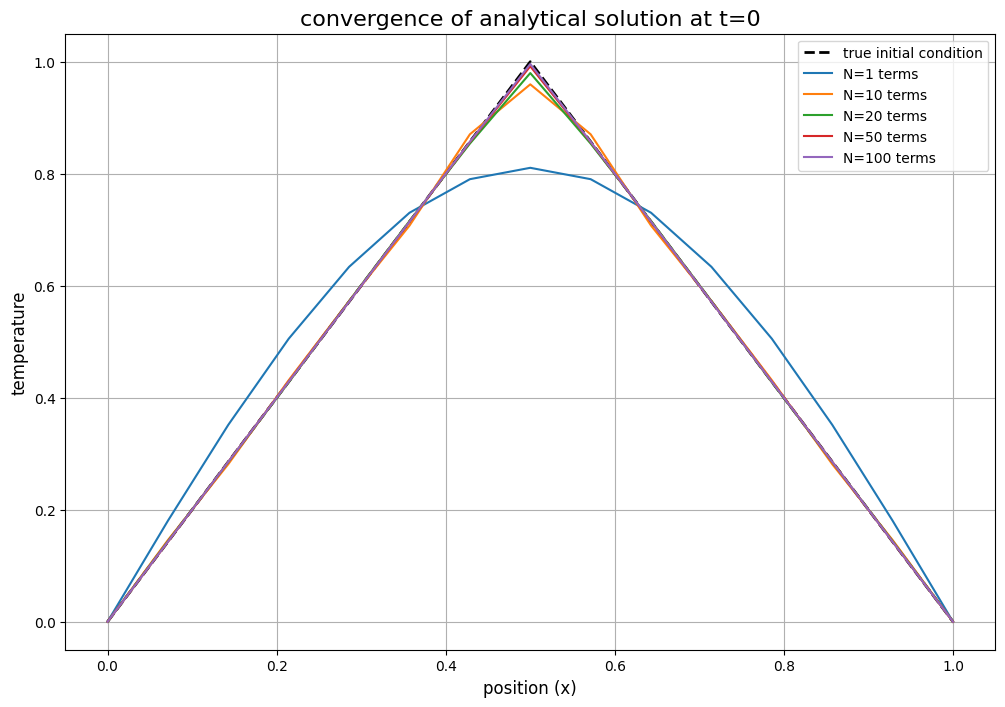

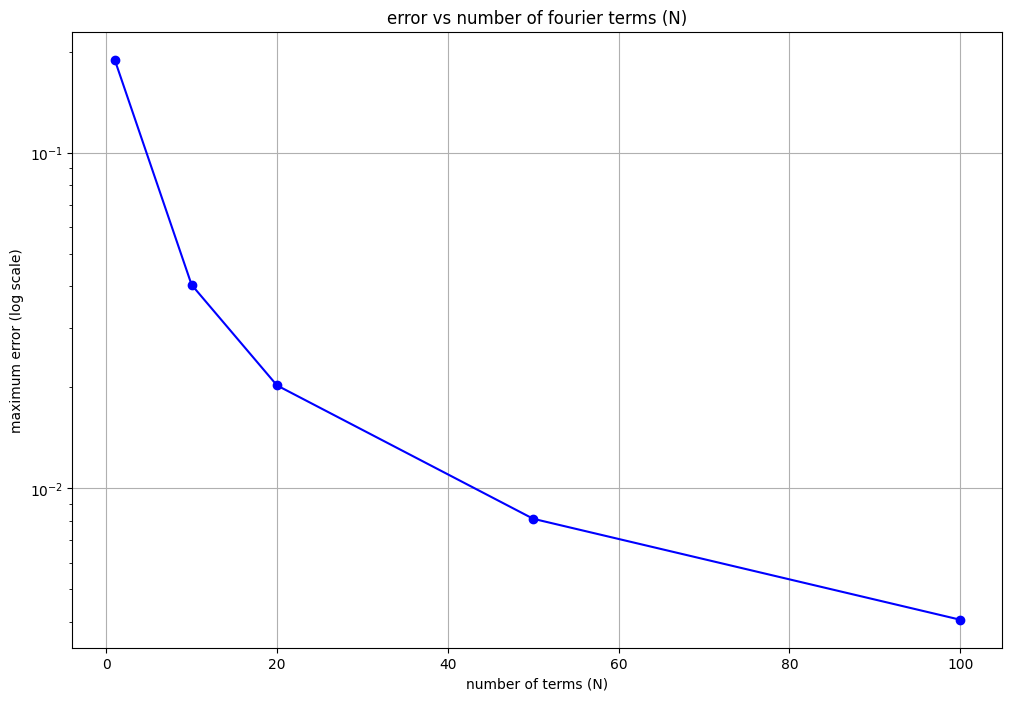

In [12]:
# cell 11: plot the 'true' initial condition for comparison
plt.figure(figsize=(12, 8))
true_ic = initial_condition_1d(x, L)
plt.plot(x, true_ic, 'k--', linewidth=2, label='true initial condition')

# list of N values to check
N_values = [1, 10, 20, 50, 100]
errors = []

for N in N_values:
    # calculate the coefficients for the current N
    b_coeffs = get_b_coeffs(N)
    
    # compute the analytical solution at t=0 for the current N
    solution = analytical_solution_1d(x, 0, alpha, L, N, b_coeffs)
    
    # plot the result
    plt.plot(x, solution, label=f'N={N} terms')
    
    # calculate and store maximum error vs true ic
    max_error = np.max(np.abs(solution - true_ic))
    errors.append(max_error)
    print(f'N={N}: max error = {max_error:.8f}')

plt.title('convergence of analytical solution at t=0', fontsize=16)
plt.xlabel('position (x)', fontsize=12)
plt.ylabel('temperature', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# plot error convergence
plt.figure(figsize=(12, 8))
plt.plot(N_values, errors, 'bo-')
plt.yscale('log')
plt.title('error vs number of fourier terms (N)')
plt.xlabel('number of terms (N)')
plt.ylabel('maximum error (log scale)')
plt.grid(True)
plt.show()

In [13]:
# cell 12: displaying 1d analytical solutions
file_name_1d = 'analytical_solutions_1d.csv'
file_path_1d = next((f for f in glob.glob(f"{output_dir}/{file_name_1d}") + glob.glob(f"{input_dir}/{file_name_1d}") if os.path.exists(f)), None)
df_analytical_1d = pd.read_csv(file_path_1d)
df_analytical_1d

,time,x,temperature
0,1.0,0.000000,0.000000e+00
1,1.0,0.071429,1.428482e-01
2,1.0,0.142857,2.857093e-01
3,1.0,0.214286,4.285795e-01
4,1.0,0.285714,5.714412e-01
...,...,...,...
895,60.0,0.714286,5.648932e-01
896,60.0,0.785714,4.273498e-01
897,60.0,0.857143,2.855468e-01
898,60.0,0.928571,1.428405e-01


In [14]:
# cell 13: displaying 2d analytical solutions
file_name_2d = 'analytical_solutions_2d.csv'
file_path_2d = next((f for f in glob.glob(f"{output_dir}/{file_name_2d}") + glob.glob(f"{input_dir}/{file_name_2d}") if os.path.exists(f)), None)
df_analytical_2d = pd.read_csv(file_path_2d)
df_analytical_2d

,time,x,y,temperature
0,1.0,0.0,0.000000,0.000000e+00
1,1.0,0.0,0.071429,0.000000e+00
2,1.0,0.0,0.142857,0.000000e+00
3,1.0,0.0,0.214286,0.000000e+00
4,1.0,0.0,0.285714,0.000000e+00
...,...,...,...,...
13495,60.0,1.0,0.714286,4.403567e-17
13496,60.0,1.0,0.785714,3.331362e-17
13497,60.0,1.0,0.857143,2.225950e-17
13498,60.0,1.0,0.928571,1.113499e-17


In [15]:
# cell 14: displaying 3d analytical solutions
file_name_3d = 'analytical_solutions_3d.csv'
file_path_3d = next((f for f in glob.glob(f"{output_dir}/{file_name_3d}") + glob.glob(f"{input_dir}/{file_name_3d}") if os.path.exists(f)), None)
df_analytical_3d = pd.read_csv(file_path_3d)
df_analytical_3d

,time,x,y,z,temperature
0,1.0,0.0,0.0,0.000000,0.000000e+00
1,1.0,0.0,0.0,0.071429,0.000000e+00
2,1.0,0.0,0.0,0.142857,0.000000e+00
3,1.0,0.0,0.0,0.214286,0.000000e+00
4,1.0,0.0,0.0,0.285714,0.000000e+00
...,...,...,...,...,...
202495,60.0,1.0,1.0,0.714286,3.432756e-33
202496,60.0,1.0,1.0,0.785714,2.596929e-33
202497,60.0,1.0,1.0,0.857143,1.735217e-33
202498,60.0,1.0,1.0,0.928571,8.680166e-34


In [16]:
# cell 15: validate analytical solutions from existing dataframes
def validate_analytical_solutions_csv():
    print("validating analytical solutions dataframes:\n")
    dim_specs = {
        '1d': (df_analytical_1d, Nx, f"{Nx} points"),
        '2d': (df_analytical_2d, Nx * Ny, f"({Nx}, {Ny}) grid"),
        '3d': (df_analytical_3d, Nx * Ny * Nz, f"({Nx}, {Ny}, {Nz}) grid"),
    }

    for dim, (df, expected_points, shape_str) in dim_specs.items():
        if df is None:
            print(f"no {dim} analytical solutions loaded!")
            continue
        print(f"validating {dim} analytical solutions:\n")
        for t in eval_times:
            temp_data = df[np.isclose(df['time'], t, rtol=1e-10)]
            if len(temp_data) != expected_points:
                print(f"warning: {dim} data mismatch: expected {expected_points}, got {len(temp_data)} for t={t:.2f}!")
            else:
                shape = expected_points if dim == '1d' else (Nx, Ny) if dim == '2d' else (Nx, Ny, Nz)
                print(f"time {t:.2f}: {shape_str} ")
        print(f"\nsuccessfully validated {dim} analytical solutions!\n\n")

validate_analytical_solutions_csv()

validating analytical solutions dataframes:

validating 1d analytical solutions:

time 1.00: 15 points 
time 2.00: 15 points 
time 3.00: 15 points 
time 4.00: 15 points 
time 5.00: 15 points 
time 6.00: 15 points 
time 7.00: 15 points 
time 8.00: 15 points 
time 9.00: 15 points 
time 10.00: 15 points 
time 11.00: 15 points 
time 12.00: 15 points 
time 13.00: 15 points 
time 14.00: 15 points 
time 15.00: 15 points 
time 16.00: 15 points 
time 17.00: 15 points 
time 18.00: 15 points 
time 19.00: 15 points 
time 20.00: 15 points 
time 21.00: 15 points 
time 22.00: 15 points 
time 23.00: 15 points 
time 24.00: 15 points 
time 25.00: 15 points 
time 26.00: 15 points 
time 27.00: 15 points 
time 28.00: 15 points 
time 29.00: 15 points 
time 30.00: 15 points 
time 31.00: 15 points 
time 32.00: 15 points 
time 33.00: 15 points 
time 34.00: 15 points 
time 35.00: 15 points 
time 36.00: 15 points 
time 37.00: 15 points 
time 38.00: 15 points 
time 39.00: 15 points 
time 40.00: 15 points 
time 41

In [17]:
# cell 16: load analytical dataframes and create lookup function for plots
def get_solution_from_df(df, time_value, dim):
    if df is None:
        raise ValueError(f"dataframe for {dim} is not loaded!")

    time_diff = np.abs(df['time'] - time_value)
    min_time_val = df['time'][time_diff.idxmin()]
    temp_data = df[np.isclose(df['time'], min_time_val, rtol=1e-10)]
    solution_values = temp_data['temperature'].values
    if len(solution_values) == 0:
        raise ValueError(f"no data found for time {min_time_val:.2f} in {dim} dataframe!")
    if dim == '1d':
        return min_time_val, solution_values
    elif dim == '2d':
        return min_time_val, solution_values.reshape(Nx, Ny)
    elif dim == '3d':
        return min_time_val, solution_values.reshape(Nx, Ny, Nz)
    else:
        raise ValueError("invalid dimension specified!")

In [18]:
# # cell 17: interactive 1d heat diffusion visualization
# time_points = eval_times
# solutions_over_time = []

# def plot_1d_diffusion(time_value):
#     try:
#         t, solution = get_solution_from_df(df_analytical_1d, time_value, '1d')
#     except ValueError as e:
#         print(f"error: {e}")
#         return

#     plt.figure(figsize=(10, 5))
#     plt.plot(x, solution, 'b-', linewidth=2, label=f'temperature at t={t:.3f}s')
#     plt.plot(x, ui_1d, 'k--', linewidth=1, alpha=0.5, label='initial condition')
    
#     plt.xlabel('position (m)', fontsize=12)
#     plt.ylabel('temperature')
#     plt.title(f'1d heat diffusion in copper rod (t = {t:.3f}s)')
#     plt.ylim([0, 1.1])
#     plt.xlim([0, L])
#     plt.grid(True, alpha=0.3)
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

# interact(plot_1d_diffusion, time_value=FloatSlider(min=time_points[0], max=t_final, step=1.0, value=time_points[0], description='time (s)', readout_format='d'))

In [19]:
# # cell 18: static snapshot plotted for saved notebooks 1d
# t, solution = get_solution_from_df(df_analytical_1d, 30.0, '1d')
# plt.figure(figsize=(10, 5))
# plt.plot(x, solution, linewidth=2) # plot temperature
# plt.plot(x, ui_1d, 'k--', linewidth=1, alpha=0.5) # plot initial condition
# plt.xlabel('position (m)')
# plt.ylabel('temperature')
# plt.title(f'1d heat diffusion in copper rod (t = {t:.3f}s)')
# plt.ylim([0, 1.1])
# plt.xlim([0, L])
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [20]:
# # cell 19: interactive 2d heat diffusion visualization
# time_points_2d = eval_times
# solutions_2d_over_time = []

# def plot_2d_diffusion(time_value):
#     try:
#         t, solution = get_solution_from_df(df_analytical_2d, time_value, '2d')
#     except ValueError as e:
#         print(f"error: {e}")
#         return
    
#     fig = plt.figure(figsize=(14, 5))
#     # 3d surface plot
#     ax1 = fig.add_subplot(121, projection='3d')
#     surf = ax1.plot_surface(X, Y, solution, cmap='coolwarm', edgecolor='none', alpha=0.8)
#     ax1.set_xlabel('x (m)')
#     ax1.set_ylabel('y (m)')
#     ax1.set_zlabel('temperature')
#     ax1.set_zlim([0, 1])
#     ax1.set_title(f'3d view (t={t:.3f}s)')
    
#     # contour plot
#     ax2 = fig.add_subplot(122)
#     contour = ax2.contourf(X, Y, solution.T, levels=20, cmap='coolwarm') 
#     ax2.set_xlabel('x (m)')
#     ax2.set_ylabel('y (m)')
#     ax2.set_title(f'contour view (t={t:.3f}s)')
#     ax2.set_aspect('equal')
#     plt.colorbar(contour, ax=ax2, label='temperature')
    
#     plt.tight_layout()
#     plt.show()

# interact(plot_2d_diffusion, time_value=FloatSlider(min=time_points_2d[0], max=t_final, step=1.0, value=time_points_2d[0], description='time (s)', readout_format='d'))

In [21]:
# # cell 20: static snapshot plotted for saved notebooks 2d
# t, solution = get_solution_from_df(df_analytical_2d, 30.0, '2d')
# fig = plt.figure(figsize=(14, 5))
# # 3d surface plot
# ax1 = fig.add_subplot(121, projection='3d')
# surf = ax1.plot_surface(X, Y, solution, cmap='coolwarm', edgecolor='none', alpha=0.8)
# ax1.set_xlabel('x (m)')
# ax1.set_ylabel('y (m)')
# ax1.set_zlabel('temperature')
# ax1.set_zlim([0, 1])
# ax1.set_title(f'3d view (t={t:.3f}s)')

# # contour plot
# ax2 = fig.add_subplot(122)
# contour = ax2.contourf(X, Y, solution.T, levels=20, cmap='coolwarm')
# ax2.set_xlabel('x (m)')
# ax2.set_ylabel('y (m)')
# ax2.set_title(f'contour view (t={t:.3f}s)')
# ax2.set_aspect('equal')
# plt.colorbar(contour, ax=ax2, label='temperature')

# plt.tight_layout()
# plt.show()

In [22]:
# # cell 21: interactive 3d heat diffusion visualization
# time_points_3d = eval_times
# solutions_3d_over_time = []

# def plot_3d_diffusion(time_value):
#     try:
#         t, solution = get_solution_from_df(df_analytical_3d, time_value, '3d')
#     except ValueError as e:
#         print(f"error: {e}")
#         return
    
#     center = Nx // 2
    
#     fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
#     # xy plane (center z)
#     im1 = axes[0].contourf(x, y, solution[:, :, center].T, levels=20, cmap='coolwarm')
#     axes[0].set_title(f'xy plane (z={z[center]:.2f}m, t={t:.3f}s)')
#     axes[0].set_xlabel('x (m)')
#     axes[0].set_ylabel('y (m)')
#     axes[0].set_aspect('equal')
#     plt.colorbar(im1, ax=axes[0])
    
#     # xz plane (center y)
#     im2 = axes[1].contourf(x, z, solution[:, center, :], levels=20, cmap='coolwarm')
#     axes[1].set_title(f'xz plane (y={y[center]:.2f}m)')
#     axes[1].set_xlabel('x (m)')
#     axes[1].set_ylabel('z (m)')
#     axes[1].set_aspect('equal')
#     plt.colorbar(im2, ax=axes[1])
    
#     # yz plane (center x)
#     im3 = axes[2].contourf(y, z, solution[center, :, :], levels=20, cmap='coolwarm') 
#     axes[2].set_title(f'yz plane (x={x[center]:.2f}m)')
#     axes[2].set_xlabel('y (m)')
#     axes[2].set_ylabel('z (m)')
#     axes[2].set_aspect('equal')
#     plt.colorbar(im3, ax=axes[2])
    
#     plt.tight_layout()
#     plt.show()

# interact(plot_3d_diffusion, time_value=FloatSlider(min=time_points_3d[0], max=t_final, step=1.0, value=time_points_3d[0], description='time (s)', readout_format='d'))

In [23]:
# # cell 22: static snapshot plotted for saved notebooks 3d
# t, solution = get_solution_from_df(df_analytical_3d, 30.0, '3d')
# center = Nx // 2
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# # xy plane at center z
# im1 = axes[0].contourf(x, y, solution[:, :, center].T, levels=20, cmap='coolwarm')
# axes[0].set_title(f'xy plane (z={z[center]:.2f}m, t={t:.3f}s)')
# axes[0].set_xlabel('x (m)')
# axes[0].set_ylabel('y (m)')
# axes[0].set_aspect('equal')
# plt.colorbar(im1, ax=axes[0])

# # xz plane at center y
# im2 = axes[1].contourf(x, z, solution[:, center, :], levels=20, cmap='coolwarm')
# axes[1].set_title(f'xz plane (y={y[center]:.2f}m)')
# axes[1].set_xlabel('x (m)')
# axes[1].set_ylabel('z (m)')
# axes[1].set_aspect('equal')
# plt.colorbar(im2, ax=axes[1])

# # yz plane at center x
# im3 = axes[2].contourf(y, z, solution[center, :, :], levels=20, cmap='coolwarm')
# axes[2].set_title(f'yz plane (x={x[center]:.2f}m)')
# axes[2].set_xlabel('y (m)')
# axes[2].set_ylabel('z (m)')
# axes[2].set_aspect('equal')
# plt.colorbar(im3, ax=axes[2])

# plt.tight_layout()
# plt.show()

## 7. FDM Solution Setup

In [24]:
# cell 23: fdm functions
def explicit_fdm_1d(u, alpha, dx, dt, apply_bc_func, bc_value=0.0):
    u_new = u.copy()
    r = alpha * dt / dx**2
    u_new[1:-1] = u[1:-1] + r * (u[2:] - 2*u[1:-1] + u[:-2])
    u_new[0] = bc_value
    u_new[-1] = bc_value
    return u_new

def implicit_fdm_1d(u, alpha, dx, dt, A_implicit, apply_bc_func, bc_value=0.0):
    u_new = u.copy()
    r = alpha * dt / dx**2
    rhs = u[1:-1].copy()
    rhs[0] += r * bc_value # left boundary contribution
    rhs[-1] += r * bc_value # right boundary contribution
    u_new[1:-1] = spsolve(A_implicit, rhs)
    u_new[0] = bc_value
    u_new[-1] = bc_value
    return u_new

def crank_nicolson_1d(u, alpha, dx, dt, A_cn, B_cn, apply_bc_func, bc_value=0.0):
    u_new = u.copy()
    r = alpha * dt / dx**2
    rhs = B_cn.dot(u[1:-1])
    rhs[0] += 0.5 * r * bc_value # left boundary (half weight for cn)
    rhs[-1] += 0.5 * r * bc_value # right boundary (half weight for cn)
    u_new[1:-1] = spsolve(A_cn, rhs)
    u_new[0] = bc_value
    u_new[-1] = bc_value
    return u_new

def setup_1d_matrices(Nx, alpha, dx, dt):
    r = alpha * dt / dx**2
    main_diag = np.ones(Nx-2) * (1 + 2*r)
    off_diag = np.ones(Nx-3) * (-r)
    A_implicit = diags([off_diag, main_diag, off_diag], [-1, 0, 1], format='csc')
    
    main_left = np.ones(Nx-2) * (1 + r)
    off_left = np.ones(Nx-3) * (-0.5*r)
    A_cn = diags([off_left, main_left, off_left], [-1, 0, 1], format='csc')
    
    main_right = np.ones(Nx-2) * (1 - r)
    off_right = np.ones(Nx-3) * (0.5*r)
    B_cn = diags([off_right, main_right, off_right], [-1, 0, 1], format='csc')
    
    return A_implicit, A_cn, B_cn

def explicit_fdm_2d(u, alpha, dx, dy, dt, bc_value=0.0):
    u_new = u.copy()
    rx = alpha * dt / dx**2
    ry = alpha * dt / dy**2
    u_new[1:-1, 1:-1] = (u[1:-1, 1:-1] + 
                         rx * (u[2:, 1:-1] - 2*u[1:-1, 1:-1] + u[:-2, 1:-1]) +
                         ry * (u[1:-1, 2:] - 2*u[1:-1, 1:-1] + u[1:-1, :-2]))
    u_new[0, :] = bc_value
    u_new[-1, :] = bc_value
    u_new[:, 0] = bc_value
    u_new[:, -1] = bc_value
    return u_new

def implicit_fdm_2d(u, alpha, dx, dy, dt, A_implicit, bc_value=0.0):
    u_new = u.copy()
    rx = alpha * dt / dx**2
    ry = alpha * dt / dy**2
    
    u_interior = u[1:-1, 1:-1].copy()
    # add boundary contributions
    u_interior[0, :] += rx * bc_value # bottom edge
    u_interior[-1, :] += rx * bc_value # top edge
    u_interior[:, 0] += ry * bc_value # left edge
    u_interior[:, -1] += ry * bc_value # right edge
    
    u_interior_new = spsolve(A_implicit, u_interior.flatten())
    u_new[1:-1, 1:-1] = u_interior_new.reshape(u.shape[0]-2, u.shape[1]-2)
    u_new[0, :] = bc_value
    u_new[-1, :] = bc_value
    u_new[:, 0] = bc_value
    u_new[:, -1] = bc_value
    return u_new

def crank_nicolson_2d(u, alpha, dx, dy, dt, A_cn, B_cn, bc_value=0.0):
    u_new = u.copy()
    rx = alpha * dt / dx**2
    ry = alpha * dt / dy**2
    
    u_interior = u[1:-1, 1:-1].flatten()
    rhs = B_cn.dot(u_interior).reshape(u.shape[0]-2, u.shape[1]-2)
    
    # add boundary contributions (half weight for cn)
    rhs[0, :] += 0.5 * rx * bc_value
    rhs[-1, :] += 0.5 * rx * bc_value
    rhs[:, 0] += 0.5 * ry * bc_value
    rhs[:, -1] += 0.5 * ry * bc_value
    
    u_interior_new = spsolve(A_cn, rhs.flatten())
    u_new[1:-1, 1:-1] = u_interior_new.reshape(u.shape[0]-2, u.shape[1]-2)
    u_new[0, :] = bc_value
    u_new[-1, :] = bc_value
    u_new[:, 0] = bc_value
    u_new[:, -1] = bc_value
    return u_new

def setup_2d_matrices(Nx, Ny, alpha, dx, dy, dt):
    d2_1d = diags([1, -2, 1], [-1, 0, 1], shape=(Nx-2, Nx-2))
    I = identity(Nx-2)
    L2D = kron(I, d2_1d) / dx**2 + kron(d2_1d, I) / dy**2
    
    A_implicit = identity((Nx-2)**2) - alpha * dt * L2D
    A_cn = identity((Nx-2)**2) - 0.5 * alpha * dt * L2D
    B_cn = identity((Nx-2)**2) + 0.5 * alpha * dt * L2D
    return A_implicit, A_cn, B_cn

def explicit_fdm_3d(u, alpha, dx, dy, dz, dt, bc_value=0.0):
    u_new = u.copy()
    rx = alpha * dt / dx**2
    ry = alpha * dt / dy**2
    rz = alpha * dt / dz**2
    u_new[1:-1, 1:-1, 1:-1] = (
        u[1:-1, 1:-1, 1:-1] +
        rx * (u[2:, 1:-1, 1:-1] - 2*u[1:-1, 1:-1, 1:-1] + u[:-2, 1:-1, 1:-1]) +
        ry * (u[1:-1, 2:, 1:-1] - 2*u[1:-1, 1:-1, 1:-1] + u[1:-1, :-2, 1:-1]) +
        rz * (u[1:-1, 1:-1, 2:] - 2*u[1:-1, 1:-1, 1:-1] + u[1:-1, 1:-1, :-2])
    )
    u_new[0, :, :] = bc_value
    u_new[-1, :, :] = bc_value
    u_new[:, 0, :] = bc_value
    u_new[:, -1, :] = bc_value
    u_new[:, :, 0] = bc_value
    u_new[:, :, -1] = bc_value
    return u_new

def implicit_fdm_3d(u, alpha, dx, dy, dz, dt, A_implicit, bc_value=0.0):
    u_new = u.copy()
    rx = alpha * dt / dx**2
    ry = alpha * dt / dy**2
    rz = alpha * dt / dz**2
    
    u_interior = u[1:-1, 1:-1, 1:-1].copy()
    # add boundary contributions
    u_interior[0, :, :] += rx * bc_value
    u_interior[-1, :, :] += rx * bc_value
    u_interior[:, 0, :] += ry * bc_value
    u_interior[:, -1, :] += ry * bc_value
    u_interior[:, :, 0] += rz * bc_value
    u_interior[:, :, -1] += rz * bc_value
    
    u_interior_new_flat = spsolve(A_implicit, u_interior.flatten())
    u_new[1:-1, 1:-1, 1:-1] = u_interior_new_flat.reshape(u.shape[0]-2, u.shape[1]-2, u.shape[2]-2)
    u_new[0, :, :] = bc_value
    u_new[-1, :, :] = bc_value
    u_new[:, 0, :] = bc_value
    u_new[:, -1, :] = bc_value
    u_new[:, :, 0] = bc_value
    u_new[:, :, -1] = bc_value
    return u_new

def crank_nicolson_3d(u, alpha, dx, dy, dz, dt, A_cn, B_cn, bc_value=0.0):
    u_new = u.copy()
    rx = alpha * dt / dx**2
    ry = alpha * dt / dy**2
    rz = alpha * dt / dz**2
    
    u_interior_flat = u[1:-1, 1:-1, 1:-1].flatten()
    rhs = B_cn.dot(u_interior_flat).reshape(u.shape[0]-2, u.shape[1]-2, u.shape[2]-2)
    
    # add boundary contributions (half weight for CN)
    rhs[0, :, :] += 0.5 * rx * bc_value
    rhs[-1, :, :] += 0.5 * rx * bc_value
    rhs[:, 0, :] += 0.5 * ry * bc_value
    rhs[:, -1, :] += 0.5 * ry * bc_value
    rhs[:, :, 0] += 0.5 * rz * bc_value
    rhs[:, :, -1] += 0.5 * rz * bc_value
    
    u_interior_new_flat = spsolve(A_cn, rhs.flatten())
    u_new[1:-1, 1:-1, 1:-1] = u_interior_new_flat.reshape(u.shape[0]-2, u.shape[1]-2, u.shape[2]-2)
    u_new[0, :, :] = bc_value
    u_new[-1, :, :] = bc_value
    u_new[:, 0, :] = bc_value
    u_new[:, -1, :] = bc_value
    u_new[:, :, 0] = bc_value
    u_new[:, :, -1] = bc_value
    return u_new

def setup_3d_matrices(Nx, Ny, Nz, alpha, dx, dy, dz, dt):
    N_interior_x = Nx - 2
    N_interior_y = Ny - 2
    N_interior_z = Nz - 2
    Total_interior_points = N_interior_x * N_interior_y * N_interior_z
    
    D2x = diags([1, -2, 1], [-1, 0, 1], shape=(N_interior_x, N_interior_x))
    D2y = diags([1, -2, 1], [-1, 0, 1], shape=(N_interior_y, N_interior_y))
    D2z = diags([1, -2, 1], [-1, 0, 1], shape=(N_interior_z, N_interior_z))
    
    Ix = identity(N_interior_x)
    Iy = identity(N_interior_y)
    Iz = identity(N_interior_z)
    
    L_x = kron(kron(Iz, Iy), D2x) / dx**2
    L_y = kron(kron(Iz, D2y), Ix) / dy**2
    L_z = kron(kron(D2z, Iy), Ix) / dz**2
    L3D = L_x + L_y + L_z
    
    A_implicit = identity(Total_interior_points) - alpha * dt * L3D
    A_cn = identity(Total_interior_points) - 0.5 * alpha * dt * L3D
    B_cn = identity(Total_interior_points) + 0.5 * alpha * dt * L3D
    
    return A_implicit, A_cn, B_cn

print("fdm functions defined successfully!")

fdm functions defined successfully!


In [25]:
# cell 24: fdm simulations
def run_fdm_simulation(dimension, noise_std=0.0):
    # generate frozen noise for this run
    noise_vector = generate_frozen_noise(n_steps, noise_std, seed=seed)
    
    if dimension == '1d' and skip_fdm_1d and noise_std == 0.0 and 'noise_levels' not in globals():
        print(f"skipping 1d fdm simulation: loading existing results!")
        df = pd.read_csv(f'{input_dir}/fdm_solutions_1d.csv')
        explicit_sols = []
        implicit_sols = []
        cn_sols = []
        for t in eval_times:
            t_data = df[np.isclose(df['time'], t, rtol=1e-10)]
            explicit_sols.append(t_data[t_data['method'] == 'explicit']['temperature'].values)
            implicit_sols.append(t_data[t_data['method'] == 'implicit']['temperature'].values)
            cn_sols.append(t_data[t_data['method'] == 'crank_nicolson']['temperature'].values)
        
        bench_df = pd.read_csv(f'{input_dir}/fdm_benchmarks.csv')
        bench_1d = bench_df[bench_df['dimension'] == '1d']
        
        performance_metrics = {}
        method_mapping = {
            'explicit': 'explicit FDM',
            'implicit': 'implicit FDM',
            'crank_nicolson': 'crank_nicolson FDM'
        }
        for method in ['explicit', 'implicit', 'crank_nicolson']:
            benchmark_method = method_mapping[method]
            method_data = bench_1d[bench_1d['method'] == benchmark_method]
            performance_metrics[method] = {
                'execution_time': method_data['execution_time_s'].iloc[0],
                'memory_usage': method_data['memory_usage_MB'].iloc[0]
            }
        
        return {
            'explicit': explicit_sols,
            'implicit': implicit_sols,
            'crank_nicolson': cn_sols,
            'performance_metrics': performance_metrics
        }

    elif dimension == '2d' and skip_fdm_2d and noise_std == 0.0 and 'noise_levels' not in globals():
        print(f"skipping 2d fdm simulation: loading existing results!")
        df = pd.read_csv(f'{input_dir}/fdm_solutions_2d.csv')
        explicit_sols = []
        implicit_sols = []
        cn_sols = []
        for t in eval_times:
            t_data = df[np.isclose(df['time'], t, rtol=1e-10)]
            explicit_data = t_data[t_data['method'] == 'explicit']['temperature'].values
            implicit_data = t_data[t_data['method'] == 'implicit']['temperature'].values  
            cn_data = t_data[t_data['method'] == 'crank_nicolson']['temperature'].values

            explicit_sols.append(explicit_data.reshape(Nx, Ny))
            implicit_sols.append(implicit_data.reshape(Nx, Ny))
            cn_sols.append(cn_data.reshape(Nx, Ny))
        
        bench_df = pd.read_csv(f'{input_dir}/fdm_benchmarks.csv')
        bench_2d = bench_df[bench_df['dimension'] == '2d']
        
        performance_metrics = {}
        method_mapping = {
            'explicit': 'explicit FDM',
            'implicit': 'implicit FDM', 
            'crank_nicolson': 'crank_nicolson FDM'
        }
        for method in ['explicit', 'implicit', 'crank_nicolson']:
            benchmark_method = method_mapping[method]
            method_data = bench_2d[bench_2d['method'] == benchmark_method]
            performance_metrics[method] = {
                'execution_time': method_data['execution_time_s'].iloc[0],
                'memory_usage': method_data['memory_usage_MB'].iloc[0]
            }
        
        return {
            'explicit': explicit_sols,
            'implicit': implicit_sols,
            'crank_nicolson': cn_sols,
            'performance_metrics': performance_metrics
        }

    elif dimension == '3d' and skip_fdm_3d and noise_std == 0.0 and 'noise_levels' not in globals():
        print(f"skipping 3d fdm simulation: loading existing results!")
        df = pd.read_csv(f'{input_dir}/fdm_solutions_3d.csv')
        explicit_sols = []
        implicit_sols = []
        cn_sols = []
        for t in eval_times:
            t_data = df[np.isclose(df['time'], t, rtol=1e-10)]
            explicit_data = t_data[t_data['method'] == 'explicit']['temperature'].values
            implicit_data = t_data[t_data['method'] == 'implicit']['temperature'].values  
            cn_data = t_data[t_data['method'] == 'crank_nicolson']['temperature'].values

            explicit_sols.append(explicit_data.reshape(Nx, Ny, Nz))
            implicit_sols.append(implicit_data.reshape(Nx, Ny, Nz))
            cn_sols.append(cn_data.reshape(Nx, Ny, Nz))
        
        bench_df = pd.read_csv(f'{input_dir}/fdm_benchmarks.csv')
        bench_3d = bench_df[bench_df['dimension'] == '3d']
        
        performance_metrics = {}
        method_mapping = {
            'explicit': 'explicit FDM',
            'implicit': 'implicit FDM', 
            'crank_nicolson': 'crank_nicolson FDM'
        }
        for method in ['explicit', 'implicit', 'crank_nicolson']:
            benchmark_method = method_mapping[method]
            method_data = bench_3d[bench_3d['method'] == benchmark_method]
            performance_metrics[method] = {
                'execution_time': method_data['execution_time_s'].iloc[0],
                'memory_usage': method_data['memory_usage_MB'].iloc[0]
            }
        
        return {
            'explicit': explicit_sols,
            'implicit': implicit_sols,
            'crank_nicolson': cn_sols,
            'performance_metrics': performance_metrics
        }
    
    # computation logic
    if dimension == '1d':
        A_implicit, A_cn, B_cn = setup_1d_matrices(Nx, alpha, dx, dt)
        u_explicit = ui_1d.copy()
        u_implicit = ui_1d.copy()
        u_cn = ui_1d.copy()

        explicit_sols = []
        implicit_sols = []
        cn_sols = []

        performance_metrics = {}

        # explicit method 1d
        start_time = time.perf_counter()
        u_explicit_temp = u_explicit.copy()
        baseline_memory = u_explicit_temp.nbytes / (1024**2)
        print(f"fdm {dimension} explicit (noise={noise_std}):")
        for step in tqdm(range(n_steps)):
            u_explicit_temp = explicit_fdm_1d(u_explicit_temp, alpha, dx, dt, boundary_conditions_1d, bc_value=noise_vector[step])
            if step in eval_indices:
                explicit_sols.append(u_explicit_temp.copy())   
        performance_metrics['explicit'] = {
            'execution_time': time.perf_counter() - start_time,
            'memory_usage': baseline_memory
        }

        # implicit method 1d
        start_time = time.perf_counter()
        u_implicit_temp = u_implicit.copy()
        baseline_memory = u_implicit_temp.nbytes / (1024**2)
        print(f"fdm {dimension} implicit (noise={noise_std}):")
        for step in tqdm(range(n_steps)):
            u_implicit_temp = implicit_fdm_1d(u_implicit_temp, alpha, dx, dt, A_implicit, boundary_conditions_1d, bc_value=noise_vector[step])
            if step in eval_indices:
                implicit_sols.append(u_implicit_temp.copy())
        performance_metrics['implicit'] = {
            'execution_time': time.perf_counter() - start_time,
            'memory_usage': baseline_memory
        }

        # crank-nicolson method 1d
        start_time = time.perf_counter()
        u_cn_temp = u_cn.copy()
        baseline_memory = u_cn_temp.nbytes / (1024**2)
        print(f"fdm {dimension} crank-nicolson (noise={noise_std}):")
        for step in tqdm(range(n_steps)):
            u_cn_temp = crank_nicolson_1d(u_cn_temp, alpha, dx, dt, A_cn, B_cn, boundary_conditions_1d, bc_value=noise_vector[step])
            if step in eval_indices:
                cn_sols.append(u_cn_temp.copy())
        performance_metrics['crank_nicolson'] = {
            'execution_time': time.perf_counter() - start_time,
            'memory_usage': baseline_memory
        }

        return {
            'explicit': explicit_sols,
            'implicit': implicit_sols,
            'crank_nicolson': cn_sols,
            'performance_metrics': performance_metrics
        }
    
    elif dimension == '2d':
        A_implicit, A_cn, B_cn = setup_2d_matrices(Nx, Ny, alpha, dx, dy, dt)
        u_explicit = ui_2d.copy()
        u_implicit = ui_2d.copy()
        u_cn = ui_2d.copy()

        explicit_sols = []
        implicit_sols = []
        cn_sols = []

        performance_metrics = {}
    
        # explicit method 2d
        start_time = time.perf_counter()
        u_explicit_temp = u_explicit.copy()
        baseline_memory = u_explicit_temp.nbytes / (1024**2)
        print(f"fdm {dimension} explicit (noise={noise_std}):")
        for step in tqdm(range(n_steps)):
            u_explicit_temp = explicit_fdm_2d(u_explicit_temp, alpha, dx, dy, dt, bc_value=noise_vector[step])
            if step in eval_indices:
                explicit_sols.append(u_explicit_temp.copy())
        performance_metrics['explicit'] = {
            'execution_time': time.perf_counter() - start_time,
            'memory_usage': baseline_memory
        }
    
        # implicit method 2d
        start_time = time.perf_counter()
        u_implicit_temp = u_implicit.copy()
        baseline_memory = u_implicit_temp.nbytes / (1024**2)
        print(f"fdm {dimension} implicit (noise={noise_std}):")
        for step in tqdm(range(n_steps)):
            u_implicit_temp = implicit_fdm_2d(u_implicit_temp, alpha, dx, dy, dt, A_implicit, bc_value=noise_vector[step])
            if step in eval_indices:
                implicit_sols.append(u_implicit_temp.copy())
        performance_metrics['implicit'] = {
            'execution_time': time.perf_counter() - start_time,
            'memory_usage': baseline_memory
        }
    
        # crank-nicolson method 2d
        start_time = time.perf_counter()
        u_cn_temp = u_cn.copy()
        baseline_memory = u_cn_temp.nbytes / (1024**2)
        print(f"fdm {dimension} crank-nicolson (noise={noise_std}):")
        for step in tqdm(range(n_steps)):
            u_cn_temp = crank_nicolson_2d(u_cn_temp, alpha, dx, dy, dt, A_cn, B_cn, bc_value=noise_vector[step])
            if step in eval_indices:
                cn_sols.append(u_cn_temp.copy())
        performance_metrics['crank_nicolson'] = {
            'execution_time': time.perf_counter() - start_time,
            'memory_usage': baseline_memory
        }
    
        return {
            'explicit': explicit_sols,
            'implicit': implicit_sols,
            'crank_nicolson': cn_sols,
            'performance_metrics': performance_metrics
        }

    elif dimension == '3d':
        A_implicit, A_cn, B_cn = setup_3d_matrices(Nx, Ny, Nz, alpha, dx, dy, dz, dt)
        u_explicit = ui_3d.copy()
        u_implicit = ui_3d.copy()
        u_cn = ui_3d.copy()

        explicit_sols = []
        implicit_sols = []
        cn_sols = []

        performance_metrics = {}
        
        # explicit method 3d
        start_time = time.perf_counter()
        u_explicit_temp = u_explicit.copy()
        baseline_memory = u_explicit_temp.nbytes / (1024**2)
        print(f"fdm {dimension} explicit (noise={noise_std}):")
        for step in tqdm(range(n_steps)):
            u_explicit_temp = explicit_fdm_3d(u_explicit_temp, alpha, dx, dy, dz, dt, bc_value=noise_vector[step])
            if step in eval_indices:
                explicit_sols.append(u_explicit_temp.copy())
        performance_metrics['explicit'] = {
            'execution_time': time.perf_counter() - start_time,
            'memory_usage': baseline_memory
        }
    
        # implicit method 3d
        start_time = time.perf_counter()
        u_implicit_temp = u_implicit.copy()
        baseline_memory = u_implicit_temp.nbytes / (1024**2)
        print(f"fdm {dimension} implicit (noise={noise_std}):")
        for step in tqdm(range(n_steps)):
            u_implicit_temp = implicit_fdm_3d(u_implicit_temp, alpha, dx, dy, dz, dt, A_implicit, bc_value=noise_vector[step])
            if step in eval_indices:
                implicit_sols.append(u_implicit_temp.copy())
        performance_metrics['implicit'] = {
            'execution_time': time.perf_counter() - start_time,
            'memory_usage': baseline_memory
        }
    
        # crank-nicolson method 3d
        start_time = time.perf_counter()
        u_cn_temp = u_cn.copy()
        baseline_memory = u_cn_temp.nbytes / (1024**2)
        print(f"fdm {dimension} crank-nicolson (noise={noise_std}):")
        for step in tqdm(range(n_steps)):
            u_cn_temp = crank_nicolson_3d(u_cn_temp, alpha, dx, dy, dz, dt, A_cn, B_cn, bc_value=noise_vector[step])
            if step in eval_indices:
                cn_sols.append(u_cn_temp.copy())    
        performance_metrics['crank_nicolson'] = {
            'execution_time': time.perf_counter() - start_time,
            'memory_usage': baseline_memory
        }
    
        return {
            'explicit': explicit_sols,
            'implicit': implicit_sols,
            'crank_nicolson': cn_sols,
            'performance_metrics': performance_metrics
        }

# run fdm simulations
print("running fdm simulations...")
fdm_results_1d = run_fdm_simulation('1d')
fdm_results_2d = run_fdm_simulation('2d')
fdm_results_3d = run_fdm_simulation('3d')

# print individual performance metrics
for dim, results in [('1D', fdm_results_1d), ('2D', fdm_results_2d), ('3D', fdm_results_3d)]:
    print(f"\n{dim} fdm performance:")
    for method in ['explicit', 'implicit', 'crank_nicolson']:
        metrics = results['performance_metrics'][method]
        print(f"{method}: \nexecution time: {metrics['execution_time']}s, \nmemory usage: {metrics['memory_usage']}mb\n")

running fdm simulations...
fdm 1d explicit (noise=0.0):


100%|██████████| 100/100 [00:00<00:00, 99983.41it/s]


fdm 1d implicit (noise=0.0):


100%|██████████| 100/100 [00:00<00:00, 7331.16it/s]


fdm 1d crank-nicolson (noise=0.0):


...

fdm 3d implicit (noise=0.0):


100%|██████████| 100/100 [00:02<00:00, 40.48it/s]


fdm 3d crank-nicolson (noise=0.0):


100%|██████████| 100/100 [00:02<00:00, 41.63it/s]


1D fdm performance:
explicit: 
execution time: 0.0027638139999908162s, 
memory usage: 0.00011444091796875mb

implicit: 
execution time: 0.015576398000121117s, 
memory usage: 0.00011444091796875mb

crank_nicolson: 
execution time: 0.009049473999766633s, 
memory usage: 0.00011444091796875mb


2D fdm performance:
explicit: 
execution time: 0.005015302000174415s, 
memory usage: 0.00171661376953125mb

implicit: 
execution time: 0.038737295000373706s, 
memory usage: 0.00171661376953125mb

crank_nicolson: 
execution time: 0.040213005999703455s, 
memory usage: 0.00171661376953125mb


3D fdm performance:
explicit: 
execution time: 0.010300766000000294s, 
memory usage: 0.02574920654296875mb

implicit: 
execution time: 2.4722125809998943s, 
memory usage: 0.02574920654296875mb

crank_nicolson: 
execution time: 2.404779961999793s, 
memory usage: 0.02574920654296875mb



In [26]:
# cell 25: save fdm solutions and compute metrics
def save_fdm_solutions():
    benchmarks = []

    # 1d fdm
    if not skip_fdm_1d:
        data_1d = []
        for method in ['explicit', 'implicit', 'crank_nicolson']:
            solutions = fdm_results_1d.get(method, [])
            for i, t in enumerate(eval_times):
                 numerical_sol = solutions[i]
                 for j, x_val in enumerate(x):
                     data_1d.append([t, method, x_val, numerical_sol[j]])
            
            metrics = fdm_results_1d['performance_metrics'][method]
            benchmarks.append({
                'dimension': '1d',
                'method': f'{method} FDM',
                'execution_time_s': metrics['execution_time'],
                'memory_usage_MB': metrics['memory_usage'],
            })
        pd.DataFrame(data_1d, columns=['time', 'method', 'x', 'temperature']).to_csv(f'{output_dir}/fdm_solutions_1d.csv', index=False)
        print("1d fdm solutions saved!")
    else:
        print("skipping 1d fdm solutions saving: valid already exists!")

    # 2d fdm
    if not skip_fdm_2d:
        data_2d = []
        for method in ['explicit', 'implicit', 'crank_nicolson']:
            solutions = fdm_results_2d.get(method, [])
            for i, t in enumerate(eval_times):
                numerical_sol = solutions[i]
                for j, x_val in enumerate(x):
                    for k, y_val in enumerate(y):
                        data_2d.append([t, method, x_val, y_val, numerical_sol[j, k]])
            
            metrics = fdm_results_2d['performance_metrics'][method]
            benchmarks.append({
                'dimension': '2d',
                'method': f'{method} FDM',
                'execution_time_s': metrics['execution_time'],
                'memory_usage_MB': metrics['memory_usage'],
            })
        pd.DataFrame(data_2d, columns=['time', 'method', 'x', 'y', 'temperature']).to_csv(f'{output_dir}/fdm_solutions_2d.csv', index=False)
        print("2d fdm solutions saved!")
    else:
        print("skipping 2d fdm solutions saving: valid file already exists!")

    # 3d fdm
    if not skip_fdm_3d:
        data_3d = []
        for method in ['explicit', 'implicit', 'crank_nicolson']:
            solutions = fdm_results_3d.get(method, [])
            for i, t in enumerate(eval_times):
                numerical_sol = solutions[i]
                for j, x_val in enumerate(x):
                    for k, y_val in enumerate(y):
                        for l, z_val in enumerate(z):
                            data_3d.append([t, method, x_val, y_val, z_val, numerical_sol[j, k, l]])

            metrics = fdm_results_3d['performance_metrics'][method]
            benchmarks.append({
                'dimension': '3d',
                'method': f'{method} FDM',
                'execution_time_s': metrics['execution_time'],
                'memory_usage_MB': metrics['memory_usage'],
            })
        pd.DataFrame(data_3d, columns=['time', 'method', 'x', 'y', 'z', 'temperature']).to_csv(f'{output_dir}/fdm_solutions_3d.csv', index=False)
        print("3d fdm solutions saved!")
    else:
        print("skipping 3d fdm solutions saving: valid file already exists!")

    # save benchmarks
    if not (skip_fdm_1d and skip_fdm_2d and skip_fdm_3d):
        pd.DataFrame(benchmarks).to_csv(f'{output_dir}/fdm_benchmarks.csv', index=False)
        print("fdm benchmarks saved!")
    else:
        print("skipping fdm benchmarks saving: valid file already exists!")

    return benchmarks

fdm_benchmarks = save_fdm_solutions()
print("\nfdm solutions and benchmarks processed!")

1d fdm solutions saved!
2d fdm solutions saved!
3d fdm solutions saved!
fdm benchmarks saved!

fdm solutions and benchmarks processed!


In [27]:
# cell 26: displaying 1d fdm solutions
file_name_fdm_1d = 'fdm_solutions_1d.csv'
file_path_fdm_1d = next((f for f in glob.glob(f"{output_dir}/{file_name_fdm_1d}") + glob.glob(f"{input_dir}/{file_name_fdm_1d}") if os.path.exists(f)), None)
df_fdm_1d = pd.read_csv(file_path_fdm_1d)
df_fdm_1d

,time,method,x,temperature
0,1.0,explicit,0.000000,0.000000
1,1.0,explicit,0.071429,0.142857
2,1.0,explicit,0.142857,0.285714
3,1.0,explicit,0.214286,0.428571
4,1.0,explicit,0.285714,0.571429
...,...,...,...,...
2695,60.0,crank_nicolson,0.714286,0.564652
2696,60.0,crank_nicolson,0.785714,0.426966
2697,60.0,crank_nicolson,0.857143,0.285385
2698,60.0,crank_nicolson,0.928571,0.142799


In [28]:
# cell 27: displaying 2d analytical solutions
file_name_fdm_2d = 'fdm_solutions_2d.csv'
file_path_fdm_2d = next((f for f in glob.glob(f"{output_dir}/{file_name_fdm_2d}") + glob.glob(f"{input_dir}/{file_name_fdm_2d}") if os.path.exists(f)), None)
df_fdm_2d = pd.read_csv(file_path_fdm_2d)
df_fdm_2d

,time,method,x,y,temperature
0,1.0,explicit,0.0,0.000000,0.0
1,1.0,explicit,0.0,0.071429,0.0
2,1.0,explicit,0.0,0.142857,0.0
3,1.0,explicit,0.0,0.214286,0.0
4,1.0,explicit,0.0,0.285714,0.0
...,...,...,...,...,...
40495,60.0,crank_nicolson,1.0,0.714286,0.0
40496,60.0,crank_nicolson,1.0,0.785714,0.0
40497,60.0,crank_nicolson,1.0,0.857143,0.0
40498,60.0,crank_nicolson,1.0,0.928571,0.0


In [29]:
# cell 28: displaying 3d fdm solutions
file_name_fdm_3d = 'fdm_solutions_3d.csv'
file_path_fdm_3d = next((f for f in glob.glob(f"{output_dir}/{file_name_fdm_3d}") + glob.glob(f"{input_dir}/{file_name_fdm_3d}") if os.path.exists(f)), None)
df_fdm_3d = pd.read_csv(file_path_fdm_3d)
df_fdm_3d

,time,method,x,y,z,temperature
0,1.0,explicit,0.0,0.0,0.000000,0.0
1,1.0,explicit,0.0,0.0,0.071429,0.0
2,1.0,explicit,0.0,0.0,0.142857,0.0
3,1.0,explicit,0.0,0.0,0.214286,0.0
4,1.0,explicit,0.0,0.0,0.285714,0.0
...,...,...,...,...,...,...
607495,60.0,crank_nicolson,1.0,1.0,0.714286,0.0
607496,60.0,crank_nicolson,1.0,1.0,0.785714,0.0
607497,60.0,crank_nicolson,1.0,1.0,0.857143,0.0
607498,60.0,crank_nicolson,1.0,1.0,0.928571,0.0


In [30]:
# cell 29: displaying fdm benchmarks
file_name_fdm_bench = 'fdm_benchmarks.csv'
file_path_fdm_bench = next((f for f in glob.glob(f"{output_dir}/{file_name_fdm_bench}") + glob.glob(f"{input_dir}/{file_name_fdm_bench}") if os.path.exists(f)), None)
df_fdm_bench = pd.read_csv(file_path_fdm_bench)
df_fdm_bench

,dimension,method,execution_time_s,memory_usage_MB
0,1d,explicit FDM,0.002764,0.000114
1,1d,implicit FDM,0.015576,0.000114
2,1d,crank_nicolson FDM,0.009049,0.000114
3,2d,explicit FDM,0.005015,0.001717
4,2d,implicit FDM,0.038737,0.001717
5,2d,crank_nicolson FDM,0.040213,0.001717
6,3d,explicit FDM,0.010301,0.025749
7,3d,implicit FDM,2.472213,0.025749
8,3d,crank_nicolson FDM,2.404780,0.025749


In [31]:
# cell 30: validate fdm results from existing dataframes
def validate_fdm_solutions_csv():
    print("validating fdm solutions dataframes:\n")
    dim_specs = {
        '1d': (df_fdm_1d, Nx, f"{Nx} points"),
        '2d': (df_fdm_2d, Nx * Ny, f"({Nx}, {Ny}) grid"),
        '3d': (df_fdm_3d, Nx * Ny * Nz, f"({Nx}, {Ny}, {Nz}) grid"),
    }

    for dim, (df, points_per_method, shape_str) in dim_specs.items():
        if df is None:
            print(f"\nno {dim} fdm results found!")
            continue

        expected_total_points = points_per_method * 3
        print(f"validating {dim} fdm solutions:\n")
        for t in eval_times:
            temp_data = df[np.isclose(df['time'], t, rtol=1e-10)]
            if len(temp_data) != expected_total_points:
                print(f"warning: t={t:.2f} expected {expected_total_points} total points (3 methods), got {len(temp_data)}!")
            print(f"time {t:.2f}: {shape_str}")
        print(f"\nsuccessfully validated {dim} fdm solution!\n\n")

validate_fdm_solutions_csv()

validating fdm solutions dataframes:

validating 1d fdm solutions:

time 1.00: 15 points
time 2.00: 15 points
time 3.00: 15 points
time 4.00: 15 points
time 5.00: 15 points
time 6.00: 15 points
time 7.00: 15 points
time 8.00: 15 points
time 9.00: 15 points
time 10.00: 15 points
time 11.00: 15 points
time 12.00: 15 points
time 13.00: 15 points
time 14.00: 15 points
time 15.00: 15 points
time 16.00: 15 points
time 17.00: 15 points
time 18.00: 15 points
time 19.00: 15 points
time 20.00: 15 points
time 21.00: 15 points
time 22.00: 15 points
time 23.00: 15 points
time 24.00: 15 points
time 25.00: 15 points
time 26.00: 15 points
time 27.00: 15 points
time 28.00: 15 points
time 29.00: 15 points
time 30.00: 15 points
time 31.00: 15 points
time 32.00: 15 points
time 33.00: 15 points
time 34.00: 15 points
time 35.00: 15 points
time 36.00: 15 points
time 37.00: 15 points
time 38.00: 15 points
time 39.00: 15 points
time 40.00: 15 points
time 41.00: 15 points
time 42.00: 15 points
time 43.00: 15 po

## 8. PINN Solution Setup

In [32]:
# cell 31: activation function definition
def get_activation(name):
    activations = {
        'tanh': nn.Tanh(),
        'gelu': nn.GELU(),
        'silu': nn.SiLU(),
        'mish': nn.Mish(),
    }
    return activations.get(name, nn.Tanh())

print("activation functions defined:")
for name in ['tanh', 'gelu', 'silu', 'mish']:
    activation = get_activation(name)
    test_input = torch.tensor([1.0], device=device)
    result = activation(test_input) if callable(activation) else activation(test_input)
    print(f"{name}: f(1.0) = {result.item():.4f}")

activation functions defined:
tanh: f(1.0) = 0.7616
gelu: f(1.0) = 0.8413
silu: f(1.0) = 0.7311
mish: f(1.0) = 0.8651


In [33]:
# cell 32: pinn model definition
class PINN(nn.Module):
    def __init__(self, input_dim, num_hidden, num_neurons, activation='tanh', initialization='xavier_uniform', input_normalization=True):
        super(PINN, self).__init__()
        self.activation_name = activation
        self.input_normalization = input_normalization
        
        layers = []
        layers.append(nn.Linear(input_dim, num_neurons))
        layers.append(get_activation(activation))
        
        for _ in range(num_hidden - 1):
            layers.append(nn.Linear(num_neurons, num_neurons))
            layers.append(get_activation(activation))
        self.layers = nn.ModuleList(layers)
        self.output = nn.Linear(num_neurons, 1)
        
        # initialize weights
        if initialization == 'xavier_uniform':
            for layer in self.layers:
                if isinstance(layer, nn.Linear):
                    nn.init.xavier_uniform_(layer.weight)
                    nn.init.zeros_(layer.bias)
            nn.init.xavier_uniform_(self.output.weight)
            nn.init.zeros_(self.output.bias)

        elif initialization == 'kaiming_normal':
            for layer in self.layers:
                if isinstance(layer, nn.Linear):
                    nn.init.kaiming_normal_(layer.weight, nonlinearity='relu') 
                    nn.init.zeros_(layer.bias)
            nn.init.kaiming_normal_(self.output.weight, nonlinearity='linear')
            nn.init.zeros_(self.output.bias)
        
    def forward(self, inputs):
        x = inputs
        
        # input normalization to [-1, 1]
        if self.input_normalization:
            bounds = torch.tensor([[0, L], [0, t_final]], device=device) if inputs.shape[1] == 2 else \
                     torch.tensor([[0, L], [0, L], [0, t_final]], device=device) if inputs.shape[1] == 3 else \
                     torch.tensor([[0, L], [0, L], [0, L], [0, t_final]], device=device)
            x = 2 * (inputs - bounds[:, 0]) / (bounds[:, 1] - bounds[:, 0]) - 1
        
        # pass through network layers
        for layer in self.layers:
            x = layer(x) if isinstance(layer, nn.Linear) else layer(x)
        x = self.output(x)
        return x

# test pinn model
test_model = PINN(input_dim=2, num_hidden=4, num_neurons=32, activation='tanh').to(device)
test_input = torch.randn(100, 2).to(device)
test_output = test_model(test_input)
print(f"pinn model test: input shape {test_input.shape} -> output shape {test_output.shape}")
print(f"model parameters: {sum(p.numel() for p in test_model.parameters())}")
del test_model, test_input, test_output
torch.cuda.empty_cache()

pinn model test: input shape torch.Size([100, 2]) -> output shape torch.Size([100, 1])
model parameters: 3297


In [34]:
# cell 33: pinn training function
def generate_lhs_points(n_points, bounds, device, seed=None):
    if seed is None:
        seed = np.random.randint(0, 1000000)
    sampler = LatinHypercube(d=len(bounds), seed=seed)
    samples = sampler.random(n=n_points)
    for i, (low, high) in enumerate(bounds):
        samples[:, i] = low + (high - low) * samples[:, i]
    return torch.tensor(samples, dtype=torch.float32, device=device)

def train_pinn(model, dimension, alpha, epochs, N_pde=2250, N_bc=750, N_ic=375, learning_rate=0.001, loss_weighting='equal', optimizer_type='adam', switch_epoch_ratio=0.90, experiment_progress=None, weight_update_freq=20, seed=seed, noise_std=0.0):
    # initialize optimizer
    # add l2 regularization (weight_decay) to prevent overfitting
    # based on experiments, adam_lbfgs likes l2, but adam-only does not.
    if optimizer_type == 'adam_lbfgs':
        l2_reg = 1e-4
    else: # 'adam'
        l2_reg = 0.0
        
    if optimizer_type == 'adam_lbfgs':
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=l2_reg)
        print(f"initial leraning rate set to: {optimizer.param_groups[0]['lr']}")
        switch_epoch = int(switch_epoch_ratio * epochs)
    elif optimizer_type == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=l2_reg)
        print(f"initial learning rate set to: {optimizer.param_groups[0]['lr']}")
    
    # scheduler
    if loss_weighting == 'adaptive_lr_annealing':
        scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99)
    else:
        scheduler = None

    # adaptive gradnorm variables
    grad_moving_avg = torch.ones(3, device=device) * 0.1 if loss_weighting == 'adaptive_gradnorm' else None
    alpha_grad = 0.7 if loss_weighting == 'adaptive_gradnorm' else None
    # persist weights across closure calls (crucial for lbfgs stability)
    current_weights = torch.ones(3, device=device)
    
    # generate points once using the deterministic seed
    if dimension == '1d':
        pde_points = generate_lhs_points(N_pde, [(0, L), (0, t_final)], device, seed=None)
        n_bc_half = N_bc // 2
        bc_points = []
        # use different seeds for bc/ic so they are deterministically different
        bc_points.append(generate_lhs_points(n_bc_half, [(0, 0), (0, t_final)], device, seed=seed+1).detach()) 
        bc_points.append(generate_lhs_points(n_bc_half, [(L, L), (0, t_final)], device, seed=seed+2).detach())
        ic_points = generate_lhs_points(N_ic, [(0, L), (0, 0)], device, seed=seed+3).detach() 

    elif dimension == '2d':
        pde_points = generate_lhs_points(N_pde, [(0, L), (0, L), (0, t_final)], device, seed=None)
        n_edge = N_bc // 4
        bc_points = []
        bc_points.append(generate_lhs_points(n_edge, [(0, 0), (0, L), (0, t_final)], device, seed=seed+1).detach())
        bc_points.append(generate_lhs_points(n_edge, [(L, L), (0, L), (0, t_final)], device, seed=seed+2).detach())
        bc_points.append(generate_lhs_points(n_edge, [(0, L), (0, 0), (0, t_final)], device, seed=seed+3).detach())
        bc_points.append(generate_lhs_points(n_edge, [(0, L), (L, L), (0, t_final)], device, seed=seed+4).detach())
        ic_points = generate_lhs_points(N_ic, [(0, L), (0, L), (0, 0)], device, seed=seed+5).detach()

    elif dimension == '3d':
        pde_points = generate_lhs_points(N_pde, [(0, L), (0, L), (0, L), (0, t_final)], device, seed=None)
        n_face = N_bc // 6
        bc_points = []
        bc_points.append(generate_lhs_points(n_face, [(0, 0), (0, L), (0, L), (0, t_final)], device, seed=seed+1).detach())
        bc_points.append(generate_lhs_points(n_face, [(L, L), (0, L), (0, L), (0, t_final)], device, seed=seed+2).detach())
        bc_points.append(generate_lhs_points(n_face, [(0, L), (0, 0), (0, L), (0, t_final)], device, seed=seed+3).detach())
        bc_points.append(generate_lhs_points(n_face, [(0, L), (L, L), (0, L), (0, t_final)], device, seed=seed+4).detach())
        bc_points.append(generate_lhs_points(n_face, [(0, L), (0, L), (0, 0), (0, t_final)], device, seed=seed+5).detach())
        bc_points.append(generate_lhs_points(n_face, [(0, L), (0, L), (L, L), (0, t_final)], device, seed=seed+6).detach())
        ic_points = generate_lhs_points(N_ic, [(0, L), (0, L), (0, L), (0, 0)], device, seed=seed+7).detach()

    # create fixed tensors for training
    pde_inputs = pde_points.requires_grad_(True) # only pde inputs need gradients
    bc_inputs = torch.cat(bc_points, dim=0) # already detached
    ic_inputs = ic_points # already detached

    # frozen noise implementation for boundary conditions
    bc_targets = torch.zeros(bc_inputs.shape[0], 1, device=device)
    
    if noise_std > 0.0:
        # generate time-varying frozen noise (matches fdm)
        noise_vector = generate_frozen_noise(n_steps, noise_std, seed=seed)
        
        # map bc points to their timestamps and apply corresponding noise
        time_idx = -1 if dimension == '1d' else (-1 if dimension == '2d' else -1) # last column is time
        bc_times = bc_inputs[:, time_idx].cpu().numpy()
        time_step_indices = np.clip((bc_times / dt).astype(int), 0, n_steps - 1)
        
        noise_values = torch.tensor(noise_vector[time_step_indices], dtype=torch.float32, device=device).unsqueeze(1)
        bc_targets = bc_targets + noise_values
        print(f"frozen noise injection (std={noise_std}): bc targets corrupted with temporal consistency!")

    loss_history = {'pde': [], 'bc': [], 'ic': [], 'total': []}

    def closure():
        optimizer.zero_grad()
        current_epoch = len(loss_history['total'])
        # access nonlocal variable for writing
        nonlocal current_weights

        # compute pde loss
        u_pde = model(pde_inputs) 
        if dimension == '1d':
            grad_u = torch.autograd.grad(u_pde, pde_inputs, torch.ones_like(u_pde), create_graph=True, retain_graph=True)[0]
            u_t = grad_u[:, 1:2]
            u_x = grad_u[:, 0:1]
            u_xx = torch.autograd.grad(u_x, pde_inputs, torch.ones_like(u_x), create_graph=True, retain_graph=True)[0][:, 0:1]
            pde_residual = u_t - alpha * u_xx
        elif dimension == '2d':
            grad_u = torch.autograd.grad(u_pde, pde_inputs, torch.ones_like(u_pde), create_graph=True, retain_graph=True)[0]
            u_t = grad_u[:, 2:3]
            u_x = grad_u[:, 0:1]
            u_y = grad_u[:, 1:2]
            u_xx = torch.autograd.grad(u_x, pde_inputs, torch.ones_like(u_x), create_graph=True, retain_graph=True)[0][:, 0:1]
            u_yy = torch.autograd.grad(u_y, pde_inputs, torch.ones_like(u_y), create_graph=True, retain_graph=True)[0][:, 1:2]
            pde_residual = u_t - alpha * (u_xx + u_yy)
        elif dimension == '3d':
            grad_u = torch.autograd.grad(u_pde, pde_inputs, torch.ones_like(u_pde), create_graph=True, retain_graph=True)[0]
            u_t = grad_u[:, 3:4]
            u_x = grad_u[:, 0:1]
            u_y = grad_u[:, 1:2]
            u_z = grad_u[:, 2:3]
            u_xx = torch.autograd.grad(u_x, pde_inputs, torch.ones_like(u_x), create_graph=True, retain_graph=True)[0][:, 0:1]
            u_yy = torch.autograd.grad(u_y, pde_inputs, torch.ones_like(u_y), create_graph=True, retain_graph=True)[0][:, 1:2]
            u_zz = torch.autograd.grad(u_z, pde_inputs, torch.ones_like(u_z), create_graph=True, retain_graph=True)[0][:, 2:3]
            pde_residual = u_t - alpha * (u_xx + u_yy + u_zz)
        loss_pde = torch.mean(pde_residual**2)

        # compute boundary loss
        u_bc = model(bc_inputs) 
        loss_bc = torch.mean((u_bc - bc_targets)**2)

        # compute initial condition loss
        u_ic = model(ic_inputs) 
        if dimension == '1d':
            x_ic = ic_inputs[:, 0:1]
            ic_true = torch.where(x_ic <= L/2, 2 * x_ic / L, 2 * (L - x_ic) / L)
        elif dimension == '2d':
            x_ic = ic_inputs[:, 0:1]
            y_ic = ic_inputs[:, 1:2]
            tri_x = torch.where(x_ic <= L/2, 2 * x_ic / L, 2 * (L - x_ic) / L)
            tri_y = torch.where(y_ic <= L/2, 2 * y_ic / L, 2 * (L - y_ic) / L)
            ic_true = tri_x * tri_y
        elif dimension == '3d':
            x_ic = ic_inputs[:, 0:1]
            y_ic = ic_inputs[:, 1:2]
            z_ic = ic_inputs[:, 2:3]
            tri_x = torch.where(x_ic <= L/2, 2 * x_ic / L, 2 * (L - x_ic) / L)
            tri_y = torch.where(y_ic <= L/2, 2 * y_ic / L, 2 * (L - y_ic) / L)
            tri_z = torch.where(z_ic <= L/2, 2 * z_ic / L, 2 * (L - z_ic) / L)
            ic_true = tri_x * tri_y * tri_z
        loss_ic = torch.mean((u_ic - ic_true)**2)

        # apply loss weighting
        if loss_weighting == 'adaptive_gradnorm':
            # only update weights if not using lbfgs
            if current_epoch % weight_update_freq == 0 and not isinstance(optimizer, torch.optim.LBFGS):
                nonlocal grad_moving_avg
                grad_pde = torch.autograd.grad(loss_pde, model.parameters(), retain_graph=True, allow_unused=True)
                grad_bc = torch.autograd.grad(loss_bc, model.parameters(), retain_graph=True, allow_unused=True)
                grad_ic = torch.autograd.grad(loss_ic, model.parameters(), retain_graph=True, allow_unused=True)
                
                norm_pde = torch.sqrt(sum(torch.sum(g**2) for g in grad_pde if g is not None))
                norm_bc = torch.sqrt(sum(torch.sum(g**2) for g in grad_bc if g is not None))
                norm_ic = torch.sqrt(sum(torch.sum(g**2) for g in grad_ic if g is not None))
                
                grad_moving_avg[0] = alpha_grad * grad_moving_avg[0] + (1 - alpha_grad) * torch.clamp(norm_pde, min=1e-8)
                grad_moving_avg[1] = alpha_grad * grad_moving_avg[1] + (1 - alpha_grad) * torch.clamp(norm_bc, min=1e-8)
                grad_moving_avg[2] = alpha_grad * grad_moving_avg[2] + (1 - alpha_grad) * torch.clamp(norm_ic, min=1e-8)

                # dimension-specific clamping
                if dimension == '3d':
                    w_pde_range = (25.0, 750.0)
                    w_bc_range = (0.1, 10.0)
                    w_ic_range = (0.1, 10.0)
                elif dimension == '2d':
                    w_pde_range = (50.0, 500.0)
                    w_bc_range = (0.1, 10.0)
                    w_ic_range = (1.0, 50.0)
                else: # 1d
                    w_pde_range = (50.0, 500.0)
                    w_bc_range = (0.1, 10.0)
                    w_ic_range = (0.1, 10.0)

                # update the persistent weights
                total_norm = torch.sum(grad_moving_avg)
                current_weights[0] = torch.clamp(total_norm / (3 * grad_moving_avg[0]), *w_pde_range)
                current_weights[1] = torch.clamp(total_norm / (3 * grad_moving_avg[1]), *w_bc_range)
                current_weights[2] = torch.clamp(total_norm / (3 * grad_moving_avg[2]), *w_ic_range)
        
            # use the current (potentially frozen) weights
            total_loss = current_weights[0] * loss_pde + current_weights[1] * loss_bc + current_weights[2] * loss_ic
        
        elif loss_weighting == 'adaptive_lr_annealing':
            # only update weights if not using lbfgs
            if not isinstance(optimizer, torch.optim.LBFGS):
                l_pde = loss_pde.detach()
                l_bc = loss_bc.detach()
                l_ic = loss_ic.detach()
                total_l = l_pde + l_bc + l_ic + 1e-8
                
                # update the persistent weights
                # dimension-specific weighting for 3d
                if dimension == '3d':
                    # boost pde contribution
                    current_weights[0] = (l_pde / total_l) * 100.0 # 100x multiplier for pde
                    current_weights[1] = l_bc / total_l
                    current_weights[2] = l_ic / total_l
                elif dimension == '2d':
                    current_weights[0] = (l_pde / total_l) * 10.0 # 10x multiplier for pde
                    current_weights[1] = l_bc / total_l
                    current_weights[2] = l_ic / total_l
                else:
                    current_weights[0] = l_pde / total_l
                    current_weights[1] = l_bc / total_l
                    current_weights[2] = l_ic / total_l
            
            # use the current (potentially frozen) weights
            total_loss = current_weights[0] * loss_pde + current_weights[1] * loss_bc + current_weights[2] * loss_ic
        
        elif loss_weighting == 'equal':
             total_loss = loss_pde + loss_bc + loss_ic
        
        # manual l2 regularization for lbfgs
        if l2_reg > 0 and isinstance(optimizer, torch.optim.LBFGS):
            l2_loss = 0
            for param in model.parameters():
                l2_loss += torch.sum(param.pow(2))
            total_loss = total_loss + (0.5 * l2_reg * l2_loss)
        
        total_loss.backward()
        
        # scale gradient clipping
        max_norm = 5.0 if dimension == '3d' else 2.5 if dimension == '2d' else 0.5
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm)
        return total_loss, loss_pde, loss_bc, loss_ic

    losses = {}
    def closure_wrapper():
        total_loss, loss_pde, loss_bc, loss_ic = closure()
        losses.update({
            'total': total_loss.item(),
            'pde': loss_pde.item(),
            'bc': loss_bc.item(),
            'ic': loss_ic.item()
        })
        return total_loss


    # track best model
    best_loss = float('inf')
    best_model_state = None
    
    # training loop
    for epoch in range(epochs):
        # we stop resampling if lbfgs is active to ensure optimization stability
        if epoch % 100 == 0 and epoch > 0 and not isinstance(optimizer, torch.optim.LBFGS):
            if dimension == '1d': bounds_res = [(0, L), (0, t_final)]
            elif dimension == '2d': bounds_res = [(0, L), (0, L), (0, t_final)]
            elif dimension == '3d': bounds_res = [(0, L), (0, L), (0, L), (0, t_final)]
            
            # generate new points and update the global tensor used by closure
            with torch.no_grad():
                pde_points = generate_lhs_points(N_pde, bounds_res, device, seed=None)
            pde_inputs = pde_points.requires_grad_(True)
        
        if optimizer_type == 'adam_lbfgs' and epoch == switch_epoch:
            print(f"switching to lbfgs at epoch {epoch}")
            optimizer = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=20, history_size=100, line_search_fn='strong_wolfe')

        optimizer.step(closure_wrapper)
        if scheduler is not None:
            scheduler.step()

        total_loss_val = losses['total']
        loss_pde_val = losses['pde']
        loss_bc_val = losses['bc']
        loss_ic_val = losses['ic']
        
        # update history
        loss_history['pde'].append(loss_pde_val)
        loss_history['bc'].append(loss_bc_val)
        loss_history['ic'].append(loss_ic_val)
        loss_history['total'].append(total_loss_val)

        # save best model state
        if total_loss_val < best_loss:
            best_loss = total_loss_val
            best_model_state = copy.deepcopy(model.state_dict())

        # early stopping for failed training
        if total_loss_val > 16.0 and epoch > 400:
            print(f"early stopping at epoch {epoch} - loss too high: {total_loss_val}")
            break
    
        # progress logging
        if epoch % 200 == 0 or epoch == epochs - 1:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"training pinn {dimension}: {epoch+1}/{epochs} epochs, lr={current_lr:.5f}, total loss={total_loss_val}, pde loss={loss_pde_val}, bc loss={loss_bc_val}, ic loss={loss_ic_val}, noise={noise_std}, gpu={torch.cuda.memory_allocated(device)//1024//1024}mb")

    # load the best model weights before returning
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"restored best model with loss: {best_loss}")

    return loss_history

print("pinn training function defined!")

pinn training function defined!


In [35]:
# cell 34: helper to validate against analytical dataframes
def validate_against_df(model, dimension, device):
    try:
        dim_df_map = {
            '1d': (df_analytical_1d, ['x', 'time']),
            '2d': (df_analytical_2d, ['x', 'y', 'time']),
            '3d': (df_analytical_3d, ['x', 'y', 'z', 'time']),
        }

        if dimension not in dim_df_map:
            raise ValueError("invalid dimension!")

        df, cols = dim_df_map[dimension]
        if df is None:
            print(f"validation skipped: analytical dataframe for {dimension} not loaded!")
            return 0.0, 0.0, 0.0

        coords = df[cols].values
        inputs = torch.tensor(coords, dtype=torch.float32, device=device)

        model.eval()
        with torch.no_grad():
            u_pred = model(inputs).cpu().numpy().ravel()

        u_true = df['temperature'].values
        diff = u_pred - u_true

        l2_error = np.sqrt(np.sum(diff ** 2))
        linf_error = np.max(np.abs(diff))

        l2_norm_true = np.sqrt(np.sum(u_true ** 2))
        rel_l2_error = l2_error / l2_norm_true if l2_norm_true > 0 else 0.0

        return l2_error, linf_error, rel_l2_error

    except Exception as e:
        print(f"validation failed: {e}!")
        return 0.0, 0.0, 0.0

In [36]:
# cell 35: pinn tuner class
class PINNTuner:
    def __init__(self, alpha, L, t_final, eval_times, grids, initial_conditions, device, epochs):
        self.alpha = alpha
        self.L = L
        self.t_final = t_final
        self.eval_times = eval_times
        self.grids = grids
        self.initial_conditions = initial_conditions
        self.device = device
        self.epochs = epochs
        self.experiment_progress = {'completed': 0, 'failed': 0, 'total': 0}

        # hyperparameter grid
        self.learning_rates = [5e-3, 5e-4]
        self.dimensions = ['1d']
        self.optimizers = ['adam', 'adam_lbfgs']
        self.switch_epoch_ratios = [0.90]
        self.initializations = ['xavier_uniform', 'kaiming_normal']
        self.input_normalization = [True]

        # dimension-specific configurations
        self.dim_specific_configs = {
            '1d': {
                'activations': ['tanh', 'gelu', 'silu', 'mish'],
                'widths': [4, 6, 8],
                'depths': [2],
                'loss_weightings': ['adaptive_gradnorm', 'adaptive_lr_annealing', 'equal']
            },
            '2d': {
                'activations': ['tanh', 'gelu', 'silu', 'mish'],
                'widths': [32, 64],
                'depths': [4, 6],
                'loss_weightings': ['equal']
            },
            '3d': {
                'activations': ['tanh', 'gelu', 'silu', 'mish'],
                'widths': [128],
                'depths': [6, 8],
                'loss_weightings': ['adaptive_gradnorm', 'adaptive_lr_annealing', 'equal']
            }
        }

    def get_adaptive_sampling(self, dim):
        if dim == '1d':
            return {'N_pde': 3000, 'N_bc': 1000, 'N_ic': 2000}
        elif dim == '2d':
            return {'N_pde': 30000, 'N_bc': 10000, 'N_ic': 20000}
        elif dim == '3d':
            return {'N_pde': 60000, 'N_bc': 20000, 'N_ic': 40000}

    def save_pinn_solutions(self, model, dimension, rel_l2_error, train_time, memory_usage, output_dir):
        # save pinn predictions to csv file
        model.eval()
        all_data = []
        
        with torch.no_grad():
            for t in self.eval_times:
                if dimension == '1d':
                    x_coords = self.grids['x_1d']
                    x_test = torch.tensor(x_coords, dtype=torch.float32, device=self.device).unsqueeze(1)
                    t_test = torch.full_like(x_test, t, device=self.device)
                    test_inputs = torch.cat([x_test, t_test], dim=1)
                    pred = model(test_inputs).cpu().numpy().flatten()
                    
                    for i, x in enumerate(x_coords):
                        all_data.append({
                            'time': t,
                            'x': x,
                            'temperature': pred[i]
                        })
                        
                elif dimension == '2d':
                    X_flat = self.grids['X_2d'].flatten()
                    Y_flat = self.grids['Y_2d'].flatten()
                    x_test = torch.tensor(X_flat, dtype=torch.float32, device=self.device).unsqueeze(1)
                    y_test = torch.tensor(Y_flat, dtype=torch.float32, device=self.device).unsqueeze(1)
                    t_test = torch.full_like(x_test, t, device=self.device)
                    test_inputs = torch.cat([x_test, y_test, t_test], dim=1)
                    pred = model(test_inputs).cpu().numpy().flatten()
                    
                    for i, (x, y) in enumerate(zip(X_flat, Y_flat)):
                        all_data.append({
                            'time': t,
                            'x': x,
                            'y': y,
                            'temperature': pred[i]
                        })
                        
                elif dimension == '3d':
                    X_flat = self.grids['X_3d'].flatten()
                    Y_flat = self.grids['Y_3d'].flatten()
                    Z_flat = self.grids['Z_3d'].flatten()
                    x_test = torch.tensor(X_flat, dtype=torch.float32, device=self.device).unsqueeze(1)
                    y_test = torch.tensor(Y_flat, dtype=torch.float32, device=self.device).unsqueeze(1)
                    z_test = torch.tensor(Z_flat, dtype=torch.float32, device=self.device).unsqueeze(1)
                    t_test = torch.full_like(x_test, t, device=self.device)
                    test_inputs = torch.cat([x_test, y_test, z_test, t_test], dim=1)
                    pred = model(test_inputs).cpu().numpy().flatten()
                    
                    for i, (x, y, z) in enumerate(zip(X_flat, Y_flat, Z_flat)):
                        all_data.append({
                            'time': t,
                            'x': x,
                            'y': y,
                            'z': z,
                            'temperature': pred[i]
                        })
        
        # save to csv
        df = pd.DataFrame(all_data)
        filename = f"pinn_solutions_{dimension}_rel_l2_{rel_l2_error:.6f}_time_{train_time:.2f}s_mem_{memory_usage:.0f}MB.csv"
        filepath = os.path.join(output_dir, filename)
        df.to_csv(filepath, index=False)
        print(f"saved: {filename}")
        return filepath

    def run_single_experiment(self, task, seed=seed, noise_std=0.0):
        depth, width, activation, learning_rate, dimension, optimizer, switch_epoch_ratio, initialization, loss_weighting, input_normalization = task

        os.environ["PYTHONHASHSEED"] = str(seed)
        
        # ensure reproducibility
        torch.manual_seed(seed)
        np.random.seed(seed)
        random.seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        try:
            torch.use_deterministic_algorithms(True)
        except Exception as e:
            print(f"Warning: Could not force deterministic algorithms: {e}")
        
        # clear cache
        torch.cuda.empty_cache()

        # get adaptive sampling
        sampling = self.get_adaptive_sampling(dimension)

        print(f"\n\ngrid config: {dimension} | depth={depth}, width={width}, activation={activation}, lr={learning_rate}, optimizer={optimizer}, loss={loss_weighting}, noise={noise_std}")
        print(f"sampling: pde={sampling['N_pde']}, bc={sampling['N_bc']}, ic={sampling['N_ic']}\n")
        
        input_dim = 2 if dimension == '1d' else (3 if dimension == '2d' else 4)
        
        # initialize model
        model = PINN(input_dim, depth, width, activation, initialization=initialization, input_normalization=input_normalization).to(self.device)
        
        # train model
        torch.cuda.reset_peak_memory_stats()
        start_time = time.perf_counter()
        
        loss_history = train_pinn(
            model, dimension, self.alpha, self.epochs,
            sampling['N_pde'], sampling['N_bc'], sampling['N_ic'],
            learning_rate, loss_weighting, optimizer, switch_epoch_ratio,
            experiment_progress=self.experiment_progress,
            seed=seed,
            noise_std=noise_std
        )
        
        train_time = time.perf_counter() - start_time
        memory_usage = torch.cuda.max_memory_allocated() / (1024**2)
        
        # validate against csv benchmark
        l2_error, linf_error, rel_l2_error = validate_against_df(model, dimension, self.device)
        print(f"returned (csv): l2={l2_error:.5f}, l∞={linf_error:.5f}, rel_l2={rel_l2_error:.5f}")
        print(f"time: {train_time:.2f}s, memory: {memory_usage:.2f}mb")

        solution_file = self.save_pinn_solutions(model, dimension, rel_l2_error, train_time, memory_usage, output_dir)

        # get final losses
        final_loss_pde = loss_history['pde'][-1]
        final_loss_bc = loss_history['bc'][-1]
        final_loss_ic = loss_history['ic'][-1]
        final_total_loss = loss_history['total'][-1]
        
        result = {
            'depth': depth,
            'width': width,
            'activation': activation,
            'learning_rate': learning_rate,
            'dimension': dimension,
            'optimizer': optimizer,
            'switch_epoch_ratio': switch_epoch_ratio,
            'initialization': initialization,
            'loss_weighting': loss_weighting,
            'input_normalization': input_normalization,
            'N_pde': sampling['N_pde'],
            'N_bc': sampling['N_bc'],
            'N_ic': sampling['N_ic'],
            'train_time': train_time,
            'total_memory': memory_usage,
            'l2_error': l2_error,
            'linf_error': linf_error,
            'rel_l2_error': rel_l2_error,
        }

        # separate loss data
        loss_data = {
            'loss_pde': final_loss_pde,
            'loss_bc': final_loss_bc,
            'loss_ic': final_loss_ic,
            'total_loss': final_total_loss,
            'loss_history': loss_history
        }
        
        # plot losses
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        epochs_range = range(1, len(loss_history['total']) + 1)
        
        loss_types = [
            ('pde', 'PDE Loss', 'b-', (0, 0)),
            ('ic', 'Initial Condition Loss', 'g-', (0, 1)),
            ('bc', 'Boundary Condition Loss', 'r-', (1, 0)),
            ('total', 'Total Loss', 'k-', (1, 1))
        ]
        
        for loss_key, title, color, pos in loss_types:
            axes[pos].plot(epochs_range, loss_history[loss_key], color, linewidth=2)
            axes[pos].set_title(f'{title.lower()} ({dimension})')
            axes[pos].set_xlabel('epoch')
            axes[pos].set_ylabel('loss')
            axes[pos].grid(True, alpha=0.3)
            axes[pos].set_yscale('log')
        
        plt.tight_layout()
        plt.show()
        plt.close()

        self.experiment_progress['completed'] += 1
        completed_count = self.experiment_progress['completed']
        total_count = self.experiment_progress['total']
        percentage = (completed_count / total_count) * 100 if total_count > 0 else 0
        
        print(f"[{completed_count}/{total_count}] ({percentage:.2f}%) completed experiment")

        torch.cuda.empty_cache()
        return result, loss_data

    def run_all_experiments(self, sample_ratio=0.1):
        global completed_pinn_tasks
        
        if skip_pinn_tuning:
            print("skipping pinn tuning: all experiments completed!")
            input_csv = f"{input_dir}/pinn_tuning_results.csv"
            output_csv = f"{output_dir}/pinn_tuning_results.csv"
            if os.path.exists(input_csv):
                pd.read_csv(input_csv).to_csv(output_csv, index=False)
                print(f"copied pinn_tuning_results.csv to {output_dir}")
            return pd.read_csv(f'{input_dir}/pinn_tuning_results.csv').to_dict('records')
    
        self.experiment_progress = {'completed': 0, 'failed': 0, 'total': 0}
    
        # generate dimension-specific tasks
        all_tasks = []
        for dim in self.dimensions:
            config = self.dim_specific_configs[dim]
            dim_tasks = list(product(
                config['depths'], config['widths'], config['activations'],
                self.learning_rates, [dim], self.optimizers, 
                self.switch_epoch_ratios, self.initializations,
                config['loss_weightings'], self.input_normalization
            ))
            all_tasks.extend(dim_tasks)
    
        # load existing results from input or output directory
        results = []
        csv_path = None
        if os.path.exists(f'{output_dir}/pinn_tuning_results.csv'):
            csv_path = f'{output_dir}/pinn_tuning_results.csv'
        elif os.path.exists(f'{input_dir}/pinn_tuning_results.csv'):
            csv_path = f'{input_dir}/pinn_tuning_results.csv'
        
        if csv_path:
            df_existing = pd.read_csv(csv_path)
            results = df_existing.to_dict('records')
            
            # update completed_pinn_tasks from the loaded csv
            task_columns = ['depth', 'width', 'activation', 'learning_rate', 'dimension', 
                            'optimizer', 'switch_epoch_ratio', 'initialization', 
                            'loss_weighting', 'input_normalization']
            completed_pinn_tasks = set()
            for _, row in df_existing[task_columns].iterrows():
                task_tuple = (
                    int(row['depth']), int(row['width']), str(row['activation']),
                    float(row['learning_rate']), str(row['dimension']), str(row['optimizer']),
                    float(row['switch_epoch_ratio']), str(row['initialization']),
                    str(row['loss_weighting']),
                    str(row['input_normalization']) == 'True' or row['input_normalization'] == True
                )
                completed_pinn_tasks.add(task_tuple)
            print(f"loaded {len(results)} previous results, {len(completed_pinn_tasks)} completed tasks")
    
        # filter out completed tasks
        tasks = [task for task in all_tasks if task not in completed_pinn_tasks]
        
        # sample tasks if needed
        if sample_ratio < 1.0:
            n_sample = int(len(all_tasks) * sample_ratio)
            np.random.shuffle(tasks)
            tasks = tasks[:n_sample]
    
        # set total for progress tracking
        self.experiment_progress['total'] = len(tasks)
    
        print(f"total combinations: {len(all_tasks)}")
        print(f"running {len(tasks)} experiments")
        print(f"already completed: {len(completed_pinn_tasks)}")
    
        for i, task in enumerate(tqdm(tasks, desc="pinn experiments")):
            try:
                result, loss_data = self.run_single_experiment(task)
                results.append(result)
                df = pd.DataFrame(results)
                df.to_csv(f'{output_dir}/pinn_tuning_results.csv', index=False)
            except Exception as e:
                self.experiment_progress['failed'] += 1
                print(f"experiment {i+1}/{len(tasks)} failed: {e}")
                torch.cuda.empty_cache()
                continue
        
        print(f"success: {self.experiment_progress['completed']}/{len(tasks)}")
        print(f"failed: {self.experiment_progress['failed']}/{len(tasks)}")
        print("results saved to pinn_tuning_results.csv")
        return results

# initialize tuner
grids = {
    'x_1d': x,
    'X_2d': X,
    'Y_2d': Y,
    'X_3d': X_3d,
    'Y_3d': Y_3d,
    'Z_3d': Z_3d
}
initial_conditions = {
    '1d': ui_1d,
    '2d': ui_2d,
    '3d': ui_3d
}

tuner = PINNTuner(alpha, L, t_final, eval_times, grids, initial_conditions, device, epochs=6000)
print("pinn tuner initialized!")

# calculate total combinations
total_combinations = sum(
    len(config['depths']) * len(config['widths']) * len(config['activations']) * len(tuner.learning_rates) * len(tuner.optimizers) * len(tuner.switch_epoch_ratios) * len(tuner.initializations) * len(config['loss_weightings']) * len(tuner.input_normalization)
    for dim, config in tuner.dim_specific_configs.items()
    if dim in tuner.dimensions
)
print(f"total possible combinations: {total_combinations}")

pinn tuner initialized!
total possible combinations: 288


In [37]:
# # cell 36: run hyperparameter tuning experiments
# tuning_results = tuner.run_all_experiments(sample_ratio=1) # 1 = all the experiments
# print(f"\ncompleted {len(tuning_results)} experiments")

In [38]:
# cell 37: test run_single_experiment
def test_experiment(task, description, epochs=6000, seed=seed):
    tuner.epochs = epochs
    tuner.experiment_progress['total'] = 1
    tuner.experiment_progress['completed'] = 0
    
    print(f"testing {description}...")
    try:
        result, loss_data = tuner.run_single_experiment(task, seed=seed)
        
        print(f"success: {description} working")
        print(f"final losses - pde: {loss_data['loss_pde']:.6e}, bc: {loss_data['loss_bc']:.6e}, ic: {loss_data['loss_ic']:.6e}")
        print(f"errors - l2: {result['l2_error']:.6e}, l∞: {result['linf_error']:.6e}, rel_l2: {result['rel_l2_error']:.6e}")
        
    except Exception as e:
        print(f"failed: {e}")

testing experiment_1d...


grid config: 1d | depth=2, width=8, activation=tanh, lr=0.005, optimizer=adam, loss=adaptive_gradnorm, noise=0.0
sampling: pde=3000, bc=1000, ic=2000

initial learning rate set to: 0.005
training pinn 1d: 1/6000 epochs, lr=0.00500, total loss=0.8427183628082275, pde loss=0.00019204990530852228, bc loss=0.7994042038917542, ic loss=0.4021836817264557, noise=0.0, gpu=64mb
training pinn 1d: 201/6000 epochs, lr=0.00500, total loss=0.0015480848960578442, pde loss=1.5053000424813945e-05, bc loss=0.00017728024977259338, ic loss=0.000833250698633492, noise=0.0, gpu=64mb
training pinn 1d: 401/6000 epochs, lr=0.00500, total loss=0.0007198483217507601, pde loss=2.6182199235336157e-06, bc loss=6.716668576700613e-05, ic loss=0.0006903508910909295, noise=0.0, gpu=64mb
training pinn 1d: 601/6000 epochs, lr=0.00500, total loss=0.0006352446507662535, pde loss=4.091664038696763e-07, bc loss=4.077874109498225e-05, ic loss=0.0006995141739025712, noise=0.0, gpu=64mb
training pinn 

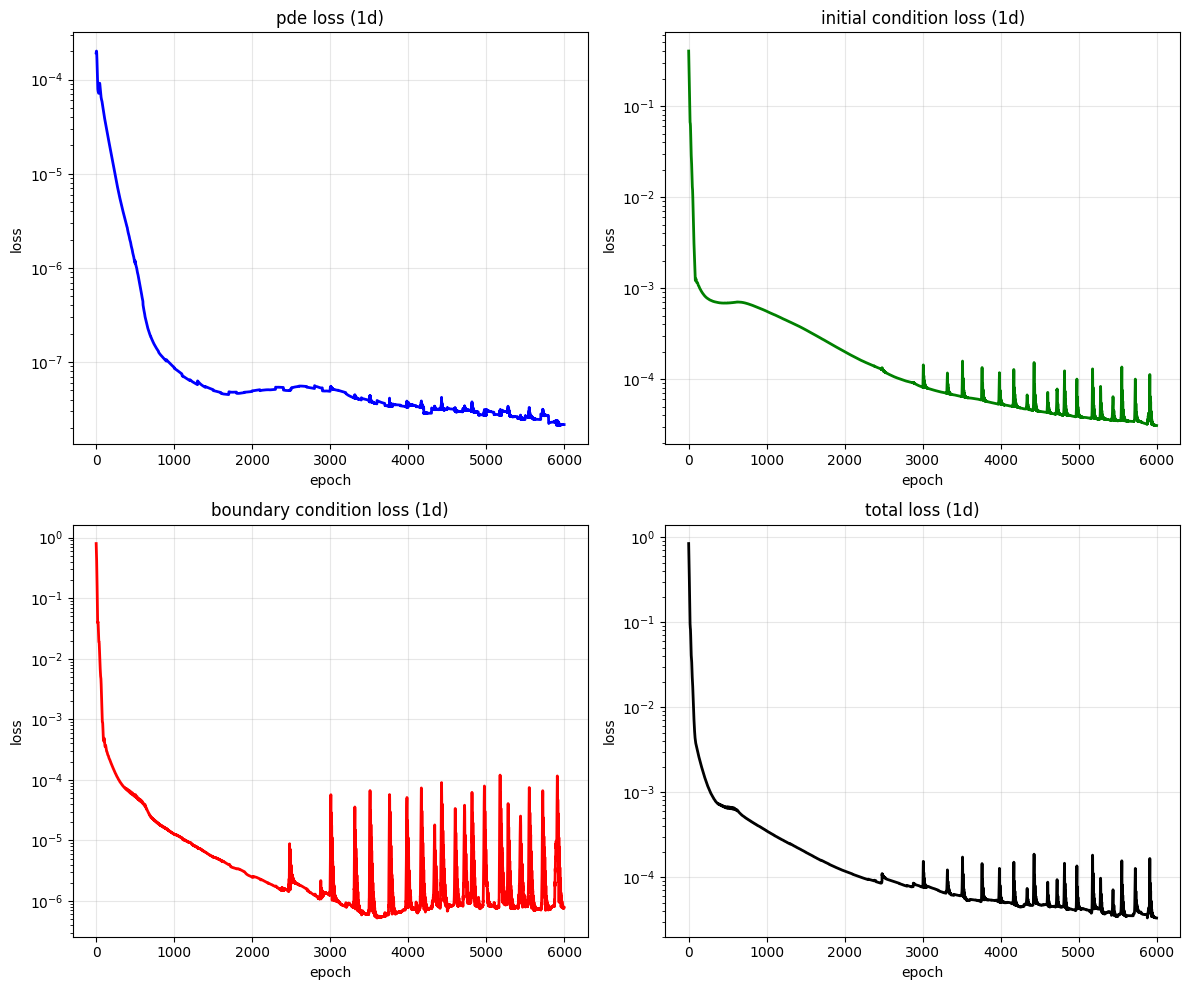

[1/1] (100.00%) completed experiment
success: experiment_1d working
final losses - pde: 2.172154e-08, bc: 7.783484e-07, ic: 3.105916e-05
errors - l2: 4.449268e-02, l∞: 1.510097e-02, rel_l2: 2.761628e-03


In [39]:
# cell 38: selection run of best result for 1d
existing_1d = glob.glob(f"{input_dir}/pinn_solutions_1d_rel_l2*.csv")

if existing_1d:
    print(f"skipping 1d pinn solutions: valid file already exists! -> {existing_1d[0]}")
else:
    test_1d = (2, 8, 'tanh', 5e-3, '1d', 'adam', 0.90, 'kaiming_normal', 'adaptive_gradnorm', True)
    test_experiment(test_1d, "experiment_1d", epochs=6000, seed=seed)

testing experiment_2d...


grid config: 2d | depth=6, width=64, activation=tanh, lr=0.0005, optimizer=adam, loss=adaptive_gradnorm, noise=0.0
sampling: pde=30000, bc=10000, ic=20000

initial learning rate set to: 0.0005
training pinn 2d: 1/6000 epochs, lr=0.00050, total loss=0.14388425648212433, pde loss=8.154904094226367e-07, bc loss=0.023319067433476448, ic loss=0.11457794904708862, noise=0.0, gpu=65mb
training pinn 2d: 201/6000 epochs, lr=0.00050, total loss=0.0019227098673582077, pde loss=2.2770474970457144e-05, bc loss=0.00024139837478287518, ic loss=0.0005770525895059109, noise=0.0, gpu=65mb
training pinn 2d: 401/6000 epochs, lr=0.00050, total loss=0.0006511311512440443, pde loss=1.2418856840668013e-06, bc loss=0.00013518155901692808, ic loss=0.0005017809453420341, noise=0.0, gpu=65mb
training pinn 2d: 601/6000 epochs, lr=0.00050, total loss=0.0007411543629132211, pde loss=7.069689331729023e-07, bc loss=0.00012722292740363628, ic loss=0.00045987515477463603, noise=0.0, gpu=65mb
t

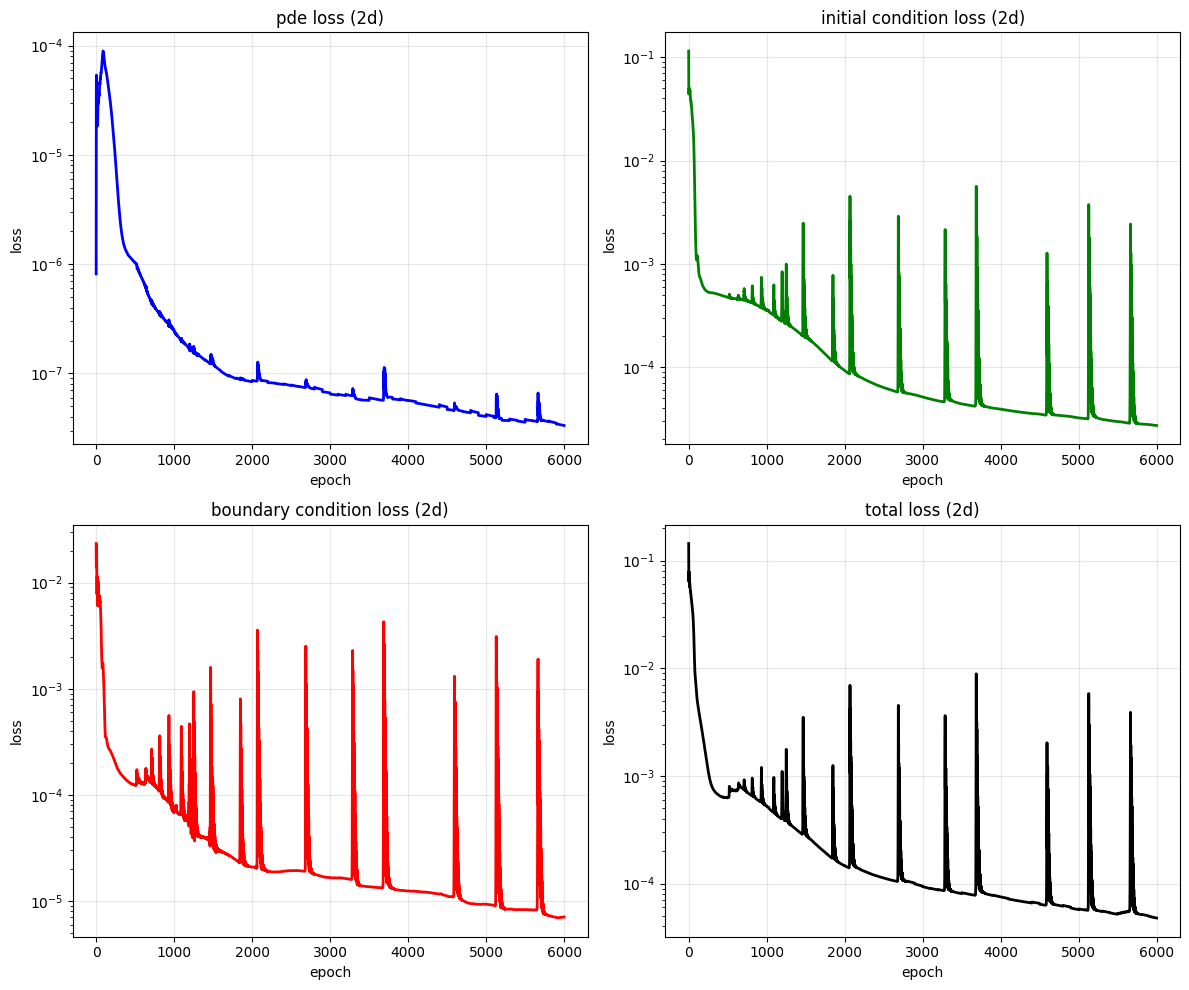

[1/1] (100.00%) completed experiment
success: experiment_2d working
final losses - pde: 3.341508e-08, bc: 7.068952e-06, ic: 2.731891e-05
errors - l2: 2.833131e-01, l∞: 3.246488e-02, rel_l2: 8.446941e-03


In [40]:
# cell 39: selection run of best result for 2d
existing_2d = glob.glob(f"{input_dir}/pinn_solutions_2d_rel_l2*.csv")

if existing_2d:
    print(f"skipping 2d pinn solutions: valid file already exists! -> {existing_2d[0]}")
else:
    test_2d = (6, 64, 'tanh', 5e-4, '2d', 'adam', 0.90, 'xavier_uniform', 'adaptive_gradnorm', True)
    test_experiment(test_2d, "experiment_2d", epochs=6000, seed=seed)

testing experiment_3d...


grid config: 3d | depth=6, width=128, activation=tanh, lr=0.0005, optimizer=adam, loss=adaptive_gradnorm, noise=0.0
sampling: pde=60000, bc=20000, ic=40000

initial learning rate set to: 0.0005
training pinn 3d: 1/6000 epochs, lr=0.00050, total loss=0.058956995606422424, pde loss=1.9738825358217582e-05, bc loss=0.03583270311355591, ic loss=0.03818085044622421, noise=0.0, gpu=68mb
training pinn 3d: 201/6000 epochs, lr=0.00050, total loss=0.0013321507722139359, pde loss=1.3330666661204305e-05, bc loss=0.0005470849573612213, ic loss=0.0008205409976653755, noise=0.0, gpu=68mb
training pinn 3d: 401/6000 epochs, lr=0.00050, total loss=0.000408770953072235, pde loss=3.622751023613091e-07, bc loss=0.00014681463653687388, ic loss=0.0003504428023006767, noise=0.0, gpu=68mb
training pinn 3d: 601/6000 epochs, lr=0.00050, total loss=0.0005026181461289525, pde loss=2.4138802245943225e-07, bc loss=0.00012941562454216182, ic loss=0.00031905059586279094, noise=0.0, gpu=68mb
t

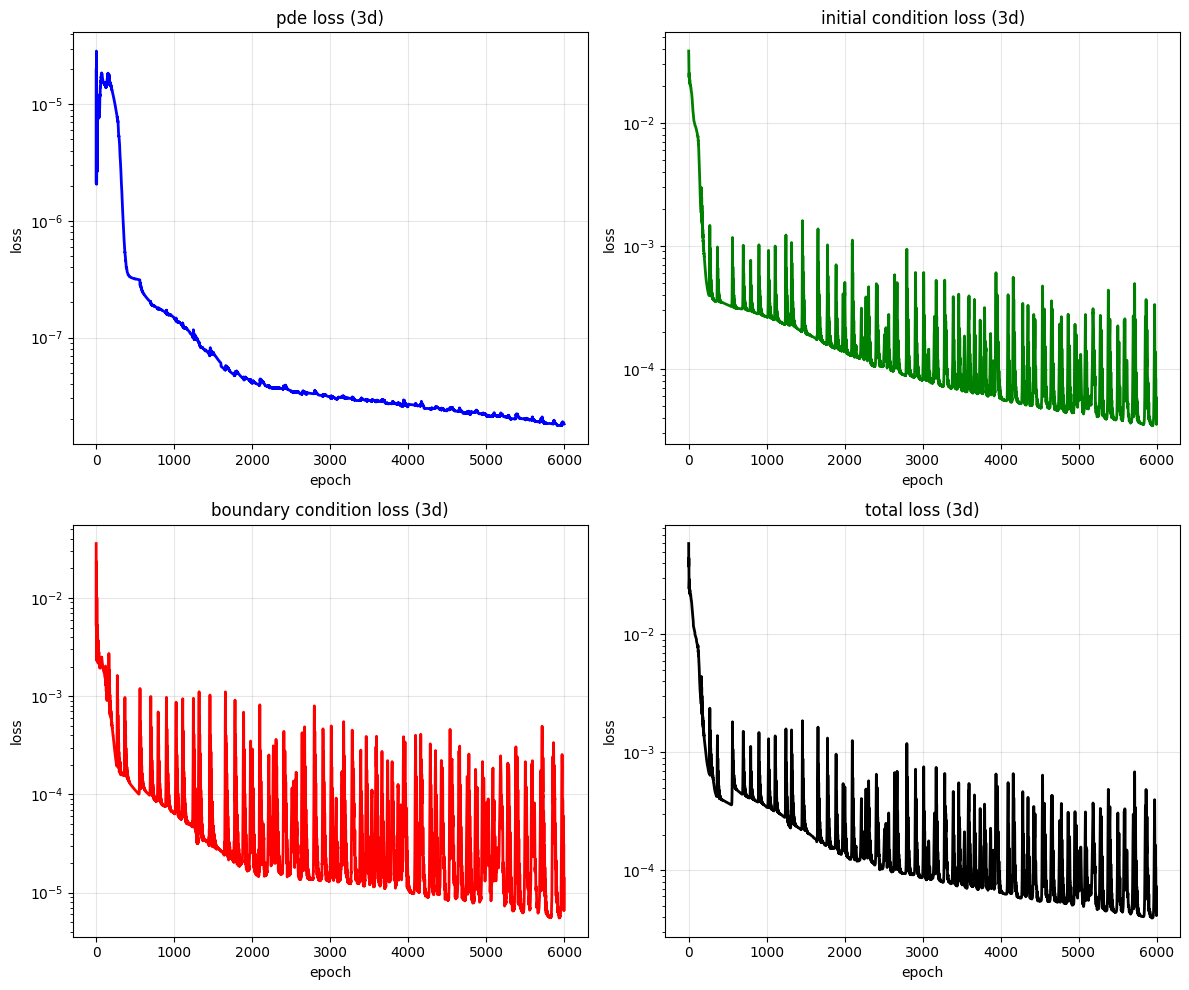

[1/1] (100.00%) completed experiment
success: experiment_3d working
final losses - pde: 1.811540e-08, bc: 1.397366e-05, ic: 4.304723e-05
errors - l2: 1.106014e+00, l∞: 8.654929e-02, rel_l2: 1.582537e-02


In [41]:
# cell 40: selection run of best result for 3d
existing_3d = glob.glob(f"{input_dir}/pinn_solutions_3d_rel_l2*.csv")

if existing_3d:
    print(f"skipping 3d pinn solutions: valid file already exists! -> {existing_3d[0]}")
else:
    test_3d = (6, 128, 'tanh', 5e-4, '3d', 'adam', 0.90, 'xavier_uniform', 'adaptive_gradnorm', True)
    test_experiment(test_3d, "experiment_3d", epochs=6000, seed=seed)

In [42]:
# cell 41: helper to find and load best pinn solution
def load_best_pinn_solution_and_metrics(dimension, output_dir, input_dir):
    file_name_pattern = f'pinn_solutions_{dimension}*.csv'
    all_files = glob.glob(f"{output_dir}/{file_name_pattern}") + glob.glob(f"{input_dir}/{file_name_pattern}")
    
    if not all_files:
        print(f"no pinn solution file found for {dimension}!")
        return None, {}

    def extract_metrics(filepath):
        # extract rel_l2_error, time, and memory from the standardized filename
        filename = os.path.basename(filepath)
        
        # regex to safely extract the three key metrics
        rel_l2_match = re.search(r'rel_l2_([\d\.]+)', filename)
        time_match = re.search(r'time_([\d\.]+)s', filename)
        mem_match = re.search(r'mem_([\d\.]+)MB', filename)
        
        try:
            rel_l2_error = float(rel_l2_match.group(1)) if rel_l2_match else float('inf')
            time_val = float(time_match.group(1)) if time_match else 0.0
            mem_val = float(mem_match.group(1)) if mem_match else 0.0
            return rel_l2_error, time_val, mem_val
        except:
            return float('inf'), 0.0, 0.0

    # find the file path with the minimum relative l2 error
    best_file_info = min([(filepath,) + extract_metrics(filepath) for filepath in all_files], key=lambda x: x[1])
    best_file_path, rel_l2_error, time_val, mem_val = best_file_info
    
    # create the required output variables
    df = pd.read_csv(best_file_path)
    performance = {'rel_l2_error': rel_l2_error, 'execution_time_s': time_val, 'memory_usage_MB': mem_val}
    
    print(f"loaded best pinn {dimension} solution from: {os.path.basename(best_file_path)}")
    print(f"best relative l2 error: {rel_l2_error:.6f}")
    
    return df, performance, rel_l2_error

pinn_solutions, pinn_performance = {}, {}

In [43]:
# cell 42: displaying 1d pinn solutions
dim = '1d'
df_pinn_1d, performance_1d, rel_l2_1d = load_best_pinn_solution_and_metrics(dim, output_dir, input_dir)
if df_pinn_1d is not None:
    pinn_solutions[dim] = df_pinn_1d
    pinn_performance[dim] = performance_1d
df_pinn_1d

loaded best pinn 1d solution from: pinn_solutions_1d_rel_l2_0.002762_time_58.16s_mem_67MB.csv
best relative l2 error: 0.002762


,time,x,temperature
0,1.0,0.000000,-0.002299
1,1.0,0.071429,0.141297
2,1.0,0.142857,0.288683
3,1.0,0.214286,0.430935
4,1.0,0.285714,0.567988
...,...,...,...
895,60.0,0.714286,0.564300
896,60.0,0.785714,0.427920
897,60.0,0.857143,0.286078
898,60.0,0.928571,0.142698


In [44]:
# cell 43: displaying 2d pinn solutions
dim = '2d'
df_pinn_2d, performance_2d, rel_l2_2d = load_best_pinn_solution_and_metrics(dim, output_dir, input_dir)
if df_pinn_2d is not None:
    pinn_solutions[dim] = df_pinn_2d
    pinn_performance[dim] = performance_2d
df_pinn_2d

loaded best pinn 2d solution from: pinn_solutions_2d_rel_l2_0.008447_time_199.24s_mem_919MB.csv
best relative l2 error: 0.008447


,time,x,y,temperature
0,1.0,0.000000,0.0,-0.010649
1,1.0,0.071429,0.0,-0.001320
2,1.0,0.142857,0.0,0.002958
3,1.0,0.214286,0.0,0.002434
4,1.0,0.285714,0.0,-0.000920
...,...,...,...,...
13495,60.0,0.714286,1.0,0.003904
13496,60.0,0.785714,1.0,0.002996
13497,60.0,0.857143,1.0,0.002350
13498,60.0,0.928571,1.0,-0.000134


In [45]:
# cell 44: displaying 3d pinn solutions
dim = '3d'
df_pinn_3d, performance_3d, rel_l2_3d = load_best_pinn_solution_and_metrics(dim, output_dir, input_dir)
if df_pinn_3d is not None:
    pinn_solutions[dim] = df_pinn_3d
    pinn_performance[dim] = performance_3d
df_pinn_3d

loaded best pinn 3d solution from: pinn_solutions_3d_rel_l2_0.015825_time_888.28s_mem_4503MB.csv
best relative l2 error: 0.015825


,time,x,y,z,temperature
0,1.0,0.0,0.0,0.000000,-0.002380
1,1.0,0.0,0.0,0.071429,-0.000696
2,1.0,0.0,0.0,0.142857,-0.000879
3,1.0,0.0,0.0,0.214286,-0.002435
4,1.0,0.0,0.0,0.285714,-0.004420
...,...,...,...,...,...
202495,60.0,1.0,1.0,0.714286,-0.003853
202496,60.0,1.0,1.0,0.785714,-0.003125
202497,60.0,1.0,1.0,0.857143,-0.001967
202498,60.0,1.0,1.0,0.928571,-0.001040


In [46]:
# cell 45: validate pinn solution grids from existing dataframes
def validate_pinn_results_csv():
    print("validating pinn solutions dataframes:\n")
    dim_specs = {
        '1d': (df_pinn_1d, Nx, f"{Nx} points"),
        '2d': (df_pinn_2d, Nx * Ny, f"({Nx}, {Ny}) grid"),
        '3d': (df_pinn_3d, Nx * Ny * Nz, f"({Nx}, {Ny}, {Nz}) grid"),
    }

    for dim, (df, points_per_time, shape_str) in dim_specs.items():
        if df is None:
            print(f"\nno {dim} pinn solutions found!")
            continue

        print(f"validating {dim} pinn solutions:\n")
        for t in eval_times:
            temp_data = df[np.isclose(df['time'], t, rtol=1e-10)]
            if len(temp_data) != points_per_time:
                print(f"warning: t={t:.2f} expected {points_per_time} points, got {len(temp_data)}!")
            print(f"time {t:.2f}: {shape_str}")
        print(f"\nsuccessfully validated {dim} pinn solutions\n\n")

validate_pinn_results_csv()

validating pinn solutions dataframes:

validating 1d pinn solutions:

time 1.00: 15 points
time 2.00: 15 points
time 3.00: 15 points
time 4.00: 15 points
time 5.00: 15 points
time 6.00: 15 points
time 7.00: 15 points
time 8.00: 15 points
time 9.00: 15 points
time 10.00: 15 points
time 11.00: 15 points
time 12.00: 15 points
time 13.00: 15 points
time 14.00: 15 points
time 15.00: 15 points
time 16.00: 15 points
time 17.00: 15 points
time 18.00: 15 points
time 19.00: 15 points
time 20.00: 15 points
time 21.00: 15 points
time 22.00: 15 points
time 23.00: 15 points
time 24.00: 15 points
time 25.00: 15 points
time 26.00: 15 points
time 27.00: 15 points
time 28.00: 15 points
time 29.00: 15 points
time 30.00: 15 points
time 31.00: 15 points
time 32.00: 15 points
time 33.00: 15 points
time 34.00: 15 points
time 35.00: 15 points
time 36.00: 15 points
time 37.00: 15 points
time 38.00: 15 points
time 39.00: 15 points
time 40.00: 15 points
time 41.00: 15 points
time 42.00: 15 points
time 43.00: 15 

## 9. Evaluation of Solutions

In [47]:
# cell 46: analysis of solution using existing dataframes + pinn metrics
print("\ndata loaded successfully!\n")
print("shape verification:")
print(
    f"\nanalytical:"
    f"\n1d = {len(df_analytical_1d)}"
    f"\n2d = {len(df_analytical_2d)}"
    f"\n3d = {len(df_analytical_3d)}"
)
print(
    f"\nfdm:"
    f"\n1d = {len(df_fdm_1d)}"
    f"\n2d = {len(df_fdm_2d)}"
    f"\n3d = {len(df_fdm_3d)}"
)
print(
    f"\npinn:"
    f"\n1d = {len(df_pinn_1d)}"
    f"\n2d = {len(df_pinn_2d)}"
    f"\n3d = {len(df_pinn_3d)}"
)
print(f"\nfdm benchmarks: {len(df_fdm_bench)}\n")

# reprint pinn metrics and performance
print("pinn performance metrics:")
for dim in ['1d', '2d', '3d']:
    perf = pinn_performance.get(dim, {})
    rel_l2_error = perf.get('rel_l2_error', None)
    time_s = perf.get('execution_time_s', None)
    mem_mb = perf.get('memory_usage_MB', None)

    print(
        f"\n{dim}:"
        f"\n  rel_l2_error = {rel_l2_error if rel_l2_error is not None else 'n/a'}"
        f"\n  execution_time_s = {time_s if time_s is not None else 'n/a'}"
        f"\n  memory_usage_MB = {mem_mb if mem_mb is not None else 'n/a'}"
    )


data loaded successfully!

shape verification:

analytical:
1d = 900
2d = 13500
3d = 202500

fdm:
1d = 2700
2d = 40500
3d = 607500

pinn:
1d = 900
2d = 13500
3d = 202500

fdm benchmarks: 9

pinn performance metrics:

1d:
  rel_l2_error = 0.002762
  execution_time_s = 58.16
  memory_usage_MB = 67.0

2d:
  rel_l2_error = 0.008447
  execution_time_s = 199.24
  memory_usage_MB = 919.0

3d:
  rel_l2_error = 0.015825
  execution_time_s = 888.28
  memory_usage_MB = 4503.0


In [48]:
# cell 47: split fdm data by method using existing dataframes
fdm_methods = ['explicit', 'implicit', 'crank_nicolson']
fdm_data_map = {
    '1d': df_fdm_1d,
    '2d': df_fdm_2d,
    '3d': df_fdm_3d,
}
fdm_split = {
    dim: {
        m: df[df['method'] == m].drop(columns='method').copy()
        for m in fdm_methods
    }
    for dim, df in fdm_data_map.items()
}
analytical_data = {
    '1d': df_analytical_1d,
    '2d': df_analytical_2d,
    '3d': df_analytical_3d,
}
print("data alignment completed!")
for dim in ['1d', '2d', '3d']:
    pinn_count = len(pinn_solutions.get(dim, []))
    print(f"\n{dim}: \nanalytical = {len(analytical_data[dim])}, \npinn = {pinn_count}")
    for method in fdm_methods:
        print(f"{method} = {len(fdm_split[dim][method])}")

data alignment completed!

1d: 
analytical = 900, 
pinn = 900
explicit = 900
implicit = 900
crank_nicolson = 900

2d: 
analytical = 13500, 
pinn = 13500
explicit = 13500
implicit = 13500
crank_nicolson = 13500

3d: 
analytical = 202500, 
pinn = 202500
explicit = 202500
implicit = 202500
crank_nicolson = 202500


In [49]:
# cell 48: function to calculate errors and merge/align data
def calculate_errors(predicted, analytical):
    # calculate l2, l∞, and relative l2 errors
    diff = predicted - analytical
    
    # l2 error
    l2_error = np.sqrt(np.sum(diff**2))
    
    # l-infinity error
    linf_error = np.max(np.abs(diff))
    
    # relative l2 error
    l2_norm_true = np.sqrt(np.sum(analytical**2))
    rel_l2_error = (l2_error / l2_norm_true) if l2_norm_true > 0 else 0
    
    return l2_error, linf_error, rel_l2_error

def merge_and_calculate_errors(analytical_df, method_df, merge_cols):
    # merge dataframes to align true and predicted solutions
    merged = pd.merge(analytical_df, method_df, on=merge_cols, suffixes=('_true', '_pred'))
    
    # calculate errors using the core function
    l2_error, linf_error, rel_l2_error = calculate_errors(
        merged['temperature_pred'].values,
        merged['temperature_true'].values
    )
    
    return l2_error, linf_error, rel_l2_error, len(merged)

print("error calculation functions defined!")

error calculation functions defined!


In [50]:
# cell 49: calculate errors for all methods and dimensions
results = []

method_mapping = {
    'explicit': 'explicit FDM',
    'implicit': 'implicit FDM', 
    'crank_nicolson': 'crank_nicolson FDM'
}

for dim in ['1d', '2d', '3d']:
    # get analytical truth data
    analytical_df = analytical_data[dim]
    
    # define merge columns based on dimension
    if dim == '1d':
        merge_cols = ['time', 'x']
    elif dim == '2d':
        merge_cols = ['time', 'x', 'y']
    else: # 3d
        merge_cols = ['time', 'x', 'y', 'z']
    
    # calculate errors for fdm methods
    for method in fdm_methods:
        method_df = fdm_split[dim][method]
        l2_error, linf_error, rel_l2_error, n_points = merge_and_calculate_errors(analytical_df, method_df, merge_cols)
        
        # get performance data from fdm_bench
        perf_data = df_fdm_bench[
            (df_fdm_bench['dimension'] == dim) & 
            (df_fdm_bench['method'] == method_mapping[method])
        ]
        
        results.append({
            'dimension': dim,
            'method': method_mapping[method],
            'l2_error': l2_error,
            'linf_error': linf_error,
            'rel_l2_error': rel_l2_error,
            'execution_time_s': perf_data['execution_time_s'].iloc[0] if len(perf_data) > 0 else np.nan,
            'memory_usage_mb': perf_data['memory_usage_MB'].iloc[0] if len(perf_data) > 0 else np.nan,
            'n_points': n_points
        })
    

    # calculate error for pinn
    if dim in pinn_solutions:
        pinn_df = pinn_solutions[dim]
        # pinn predictions are stored against the same coordinate grid as analytical data
        l2_error, linf_error, rel_l2_error, n_points = merge_and_calculate_errors(analytical_df, pinn_df, merge_cols)
        
        # performance data is pulled from the pinn_performance dictionary
        results.append({
            'dimension': dim,
            'method': 'PINN',
            'l2_error': l2_error,
            'linf_error': linf_error,
            'rel_l2_error': rel_l2_error,
            'execution_time_s': pinn_performance[dim]['execution_time_s'],
            'memory_usage_mb': pinn_performance[dim]['memory_usage_MB'],
            'n_points': n_points
        })

# create results dataframe
results_df = pd.DataFrame(results)
print("\ncomprehensive result:")
results_df


comprehensive result:


,dimension,method,l2_error,linf_error,rel_l2_error,execution_time_s,memory_usage_mb,n_points
0,1d,explicit FDM,0.121047,0.022753,0.007513,0.002764,0.000114,900
1,1d,implicit FDM,0.126974,0.023425,0.007881,0.015576,0.000114,900
2,1d,crank_nicolson FDM,0.124011,0.023094,0.007697,0.009049,0.000114,900
3,1d,PINN,0.044493,0.015101,0.002762,58.160000,67.000000,900
4,2d,explicit FDM,0.406411,0.043456,0.012117,0.005015,0.001717,13500
5,2d,implicit FDM,0.425294,0.044932,0.012680,0.038737,0.001717,13500
6,2d,crank_nicolson FDM,0.415848,0.044206,0.012398,0.040213,0.001717,13500
7,2d,PINN,0.283313,0.032465,0.008447,199.240000,919.000000,13500
8,3d,explicit FDM,1.150253,0.062246,0.016458,0.010301,0.025749,202500
9,3d,implicit FDM,1.204401,0.064643,0.017233,2.472213,0.025749,202500


In [51]:
# cell 50: performance ranking with relative l2 error
ranking_df = (
    results_df
    .sort_values(['dimension', 'rel_l2_error'])
    .assign(rank=lambda d: d.groupby('dimension').cumcount() + 1)
    [['dimension', 'rank', 'method', 'rel_l2_error', 'execution_time_s']]
)

print("performance ranking (by relative l2 error):")
ranking_df

performance ranking (by relative l2 error):


,dimension,rank,method,rel_l2_error,execution_time_s
3,1d,1,PINN,0.002762,58.160000
0,1d,2,explicit FDM,0.007513,0.002764
2,1d,3,crank_nicolson FDM,0.007697,0.009049
1,1d,4,implicit FDM,0.007881,0.015576
7,2d,1,PINN,0.008447,199.240000
4,2d,2,explicit FDM,0.012117,0.005015
6,2d,3,crank_nicolson FDM,0.012398,0.040213
5,2d,4,implicit FDM,0.012680,0.038737
11,3d,1,PINN,0.015825,888.280000
8,3d,2,explicit FDM,0.016458,0.010301


In [52]:
# cell 51: detailed accuracy dataframe
accuracy_df = (
    results_df
    .assign(accuracy_percent=lambda d: (1 - d['rel_l2_error']).clip(lower=0) * 100)
    [['dimension', 'method', 'rel_l2_error', 'accuracy_percent']]
)

print("\ndetailed accuracy results:")
accuracy_df


detailed accuracy results:


,dimension,method,rel_l2_error,accuracy_percent
0,1d,explicit FDM,0.007513,99.248670
1,1d,implicit FDM,0.007881,99.211881
2,1d,crank_nicolson FDM,0.007697,99.230270
3,1d,PINN,0.002762,99.723837
4,2d,explicit FDM,0.012117,98.788291
5,2d,implicit FDM,0.012680,98.731993
6,2d,crank_nicolson FDM,0.012398,98.760156
7,2d,PINN,0.008447,99.155306
8,3d,explicit FDM,0.016458,98.354163
9,3d,implicit FDM,0.017233,98.276686


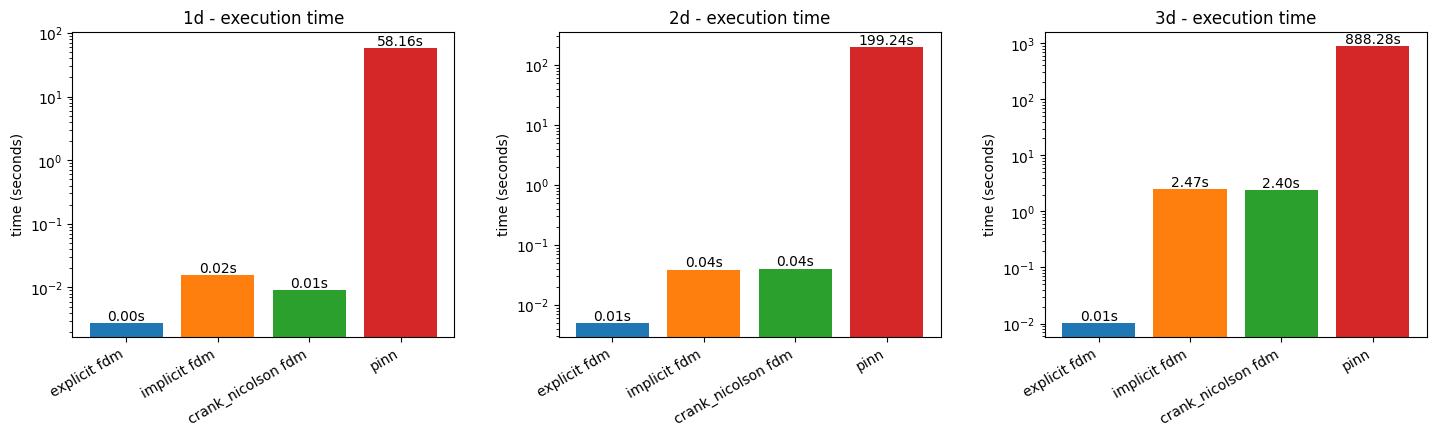

In [53]:
# cell 52: execution time comparison
# shared, consistent color map across plots
method_colors = {
    'explicit FDM': '#1f77b4',
    'implicit FDM': '#ff7f0e',
    'crank_nicolson FDM': '#2ca02c',
    'PINN': '#d62728',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, dim in zip(axes, ['1d', '2d', '3d']):
    dim_data = results_df.query("dimension == @dim")

    bars = ax.bar(
        dim_data['method'],
        dim_data['execution_time_s'],
        color=[method_colors[m] for m in dim_data['method']]
    )

    ax.set_title(f'{dim} - execution time')
    ax.set_ylabel('time (seconds)')
    ax.set_yscale('log')
    ax.set_ylim(top=dim_data['execution_time_s'].max() * 1.8)

    ax.set_xticklabels([m.lower() for m in dim_data['method']], rotation=30, ha='right')

    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h,
            f'{h:.2f}s',
            ha='center',
            va='bottom'
        )

plt.tight_layout(pad=3.0)
plt.savefig('time.png', dpi=300, bbox_inches='tight')
plt.show()

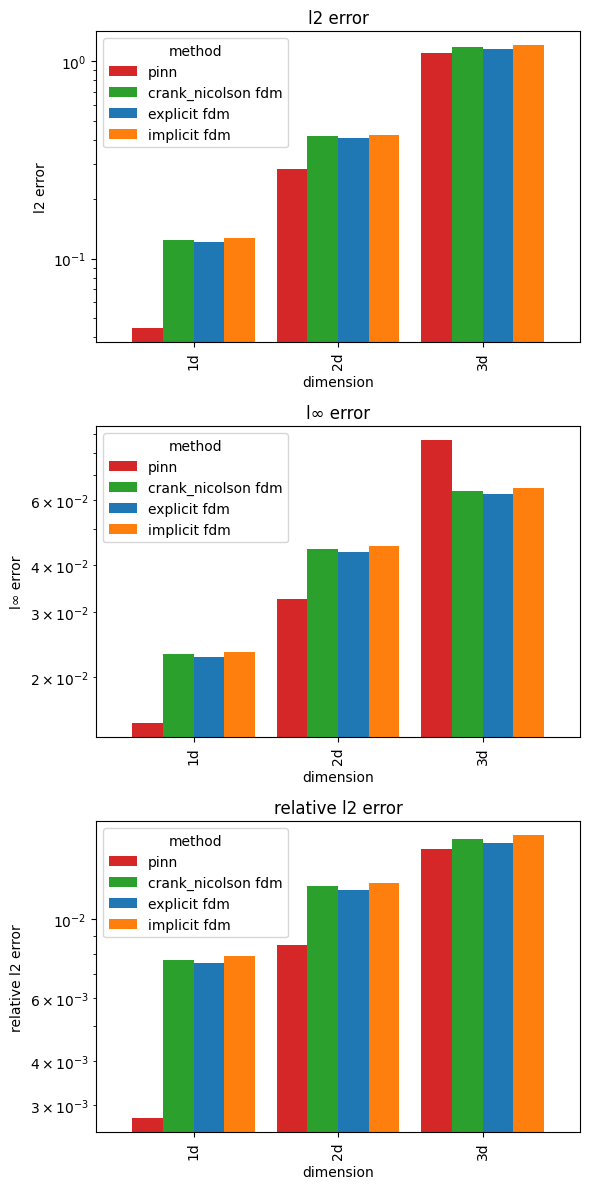

In [54]:
# cell 53: error comparison
metrics = [
    ('l2_error', 'l2 error'),
    ('linf_error', 'l∞ error'),
    ('rel_l2_error', 'relative l2 error'),
]

fig, axes = plt.subplots(3, 1, figsize=(6, 12))
for ax, (metric, title) in zip(axes, metrics):
    pivot = (
        results_df
        .pivot(index='dimension', columns='method', values=metric)
        .sort_index()
    )

    pivot.plot(
        kind='bar',
        ax=ax,
        logy=True,
        width=0.85,
        color=[method_colors[m] for m in pivot.columns]
    )

    ax.set_title(title)
    ax.set_xlabel('dimension')
    ax.set_ylabel(title)
    ax.legend(title='method', labels=[m.lower() for m in pivot.columns])

plt.tight_layout()
plt.savefig('comparison_error.png', dpi=300, bbox_inches='tight')
plt.show()

In [55]:
# cell 54: solution and error plots for all dimensions
plot_styles = {
    'analytical': {'color': '#FFD700', 'linewidth': 6.5, 'alpha': 0.70, 'linestyle': '-', 'label': 'analytical', 'zorder': 1},
    'explicit': {'color': '#0066CC', 'linewidth': 4.0, 'alpha': 0.75, 'linestyle': '--', 'label': 'explicit fdm', 'zorder': 2},
    'implicit': {'color': '#FF3366', 'linewidth': 3.0, 'alpha': 0.90, 'linestyle': '-.', 'label': 'implicit fdm', 'zorder': 3},
    'crank_nicolson': {'color': '#39FF14', 'linewidth': 3.0, 'alpha': 1.0, 'linestyle': ':', 'label': 'crank-nicolson fdm', 'zorder': 4},
    'pinn': {'color': '#000000', 'linewidth': 1.0, 'alpha': 0.8, 'linestyle': '-', 'label': 'pinn', 'zorder': 5}
}

def get_selected_times(df, target_times):
    # find closest matching times in dataframe
    actual_times = sorted(df['time'].unique())
    selected = []
    for target in target_times:
        for actual in actual_times:
            if np.isclose(actual, target, atol=1e-3):
                selected.append(actual)
                break
    return selected

def plot_dimension(dim, analytical_df, fdm_dict, pinn_df, times, cross_sections=None):
    # generate solution and error plots for given dimension
    n_times = len(times)
    fig, axes = plt.subplots(n_times, 2, figsize=(10, 4*n_times))
    if n_times == 1:
        axes = axes.reshape(1, -1)
    
    for i, t in enumerate(times):
        # filter data at time t
        analytical_t = analytical_df[np.isclose(analytical_df['time'], t, atol=1e-6)]
        explicit_t = fdm_dict['explicit'][np.isclose(fdm_dict['explicit']['time'], t, atol=1e-6)]
        implicit_t = fdm_dict['implicit'][np.isclose(fdm_dict['implicit']['time'], t, atol=1e-6)]
        crank_t = fdm_dict['crank_nicolson'][np.isclose(fdm_dict['crank_nicolson']['time'], t, atol=1e-6)]
        pinn_t = pinn_df[np.isclose(pinn_df['time'], t, atol=1e-6)]
        
        # apply cross-sections for 2d/3d
        if cross_sections:
            for coord, val in cross_sections.items():
                analytical_t = analytical_t[np.isclose(analytical_t[coord], val, atol=1e-6)]
                explicit_t = explicit_t[np.isclose(explicit_t[coord], val, atol=1e-6)]
                implicit_t = implicit_t[np.isclose(implicit_t[coord], val, atol=1e-6)]
                crank_t = crank_t[np.isclose(crank_t[coord], val, atol=1e-6)]
                pinn_t = pinn_t[np.isclose(pinn_t[coord], val, atol=1e-6)]
        
        # sort by x
        analytical_t = analytical_t.sort_values('x')
        explicit_t = explicit_t.sort_values('x')
        implicit_t = implicit_t.sort_values('x')
        crank_t = crank_t.sort_values('x')
        pinn_t = pinn_t.sort_values('x')
        
        # temperature plot
        ax = axes[i, 0]
        ax.plot(analytical_t['x'], analytical_t['temperature'], **plot_styles['analytical'])
        ax.plot(explicit_t['x'], explicit_t['temperature'], **plot_styles['explicit'])
        ax.plot(implicit_t['x'], implicit_t['temperature'], **plot_styles['implicit'])
        ax.plot(crank_t['x'], crank_t['temperature'], **plot_styles['crank_nicolson'])
        ax.plot(pinn_t['x'], pinn_t['temperature'], **plot_styles['pinn'])
        
        title_suffix = ''
        if cross_sections:
            title_suffix = ', ' + ', '.join([f'{k} = {v}' for k, v in cross_sections.items()])
        ax.set_title(f'{dim} temperature at t = {t:.3f}s{title_suffix}')
        ax.set_xlabel('x (meter)')
        ax.set_ylabel('temperature')
        ax.grid(True, alpha=0.3)
        ax.legend()
        
        # error plot
        ax = axes[i, 1]
        error_explicit = np.abs(explicit_t['temperature'].values - analytical_t['temperature'].values) + 1e-15
        error_implicit = np.abs(implicit_t['temperature'].values - analytical_t['temperature'].values) + 1e-15
        error_crank = np.abs(crank_t['temperature'].values - analytical_t['temperature'].values) + 1e-15
        error_pinn = np.abs(pinn_t['temperature'].values - analytical_t['temperature'].values) + 1e-15
        
        ax.semilogy(analytical_t['x'], error_explicit, **{**plot_styles['explicit'], 'label': 'explicit error'})
        ax.semilogy(analytical_t['x'], error_implicit, **{**plot_styles['implicit'], 'label': 'implicit error'})
        ax.semilogy(analytical_t['x'], error_crank, **{**plot_styles['crank_nicolson'], 'label': 'crank-nicolson error'})
        ax.semilogy(analytical_t['x'], error_pinn, **{**plot_styles['pinn'], 'label': 'pinn error'})
        
        ax.set_title(f'{dim} error at t = {t:.3f}s')
        ax.set_xlabel('x (meter)')
        ax.set_ylabel('absolute error (log scale)')
        ax.grid(True, alpha=0.3)
        ax.legend()
    
    plt.tight_layout()
    plt.savefig(f'{dim}_plots.png', dpi=300, bbox_inches='tight')
    plt.show()

# generate plots for all dimensions
target_times = [1, 30, 60]

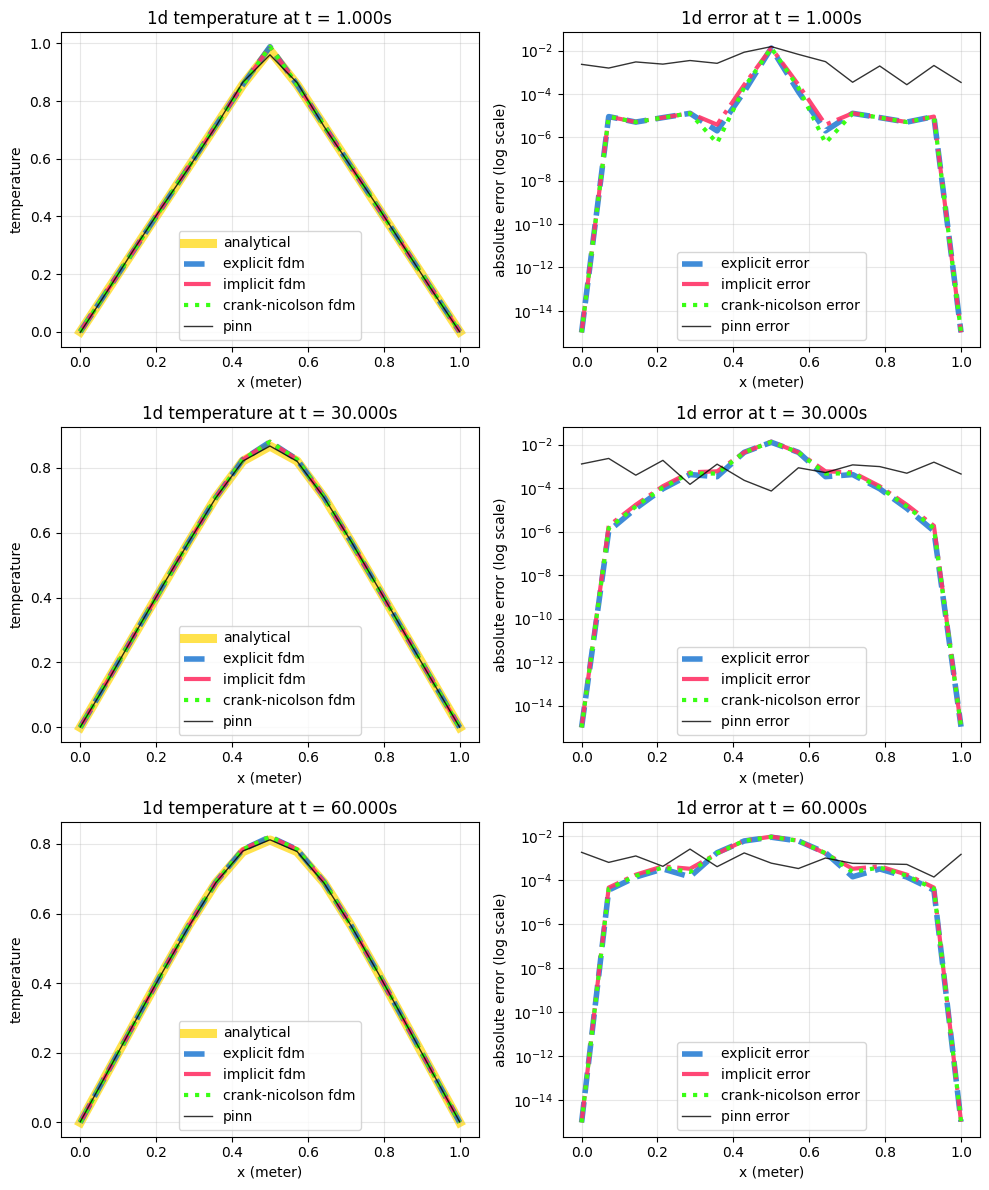

In [56]:
# cell 55: 1d heat equation line plots
times_1d = get_selected_times(df_analytical_1d, target_times)
plot_dimension('1d', df_analytical_1d, fdm_split['1d'], pinn_solutions['1d'], times_1d)

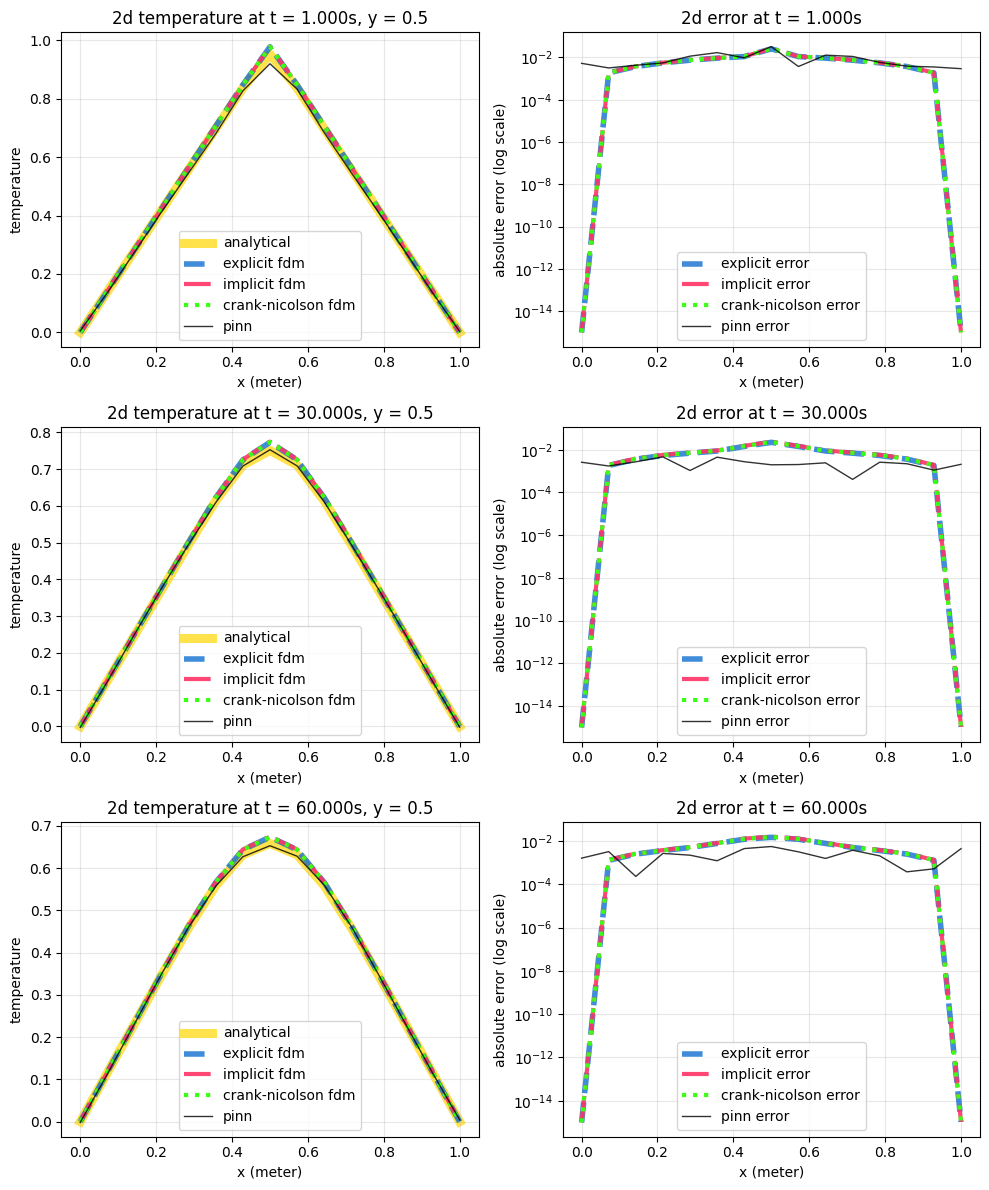

In [57]:
# cell 56: 2d heat equation cross-sectional plots of solution and error
times_2d = get_selected_times(df_analytical_2d, target_times)
plot_dimension('2d', df_analytical_2d, fdm_split['2d'], pinn_solutions['2d'], times_2d, cross_sections={'y': 0.5})

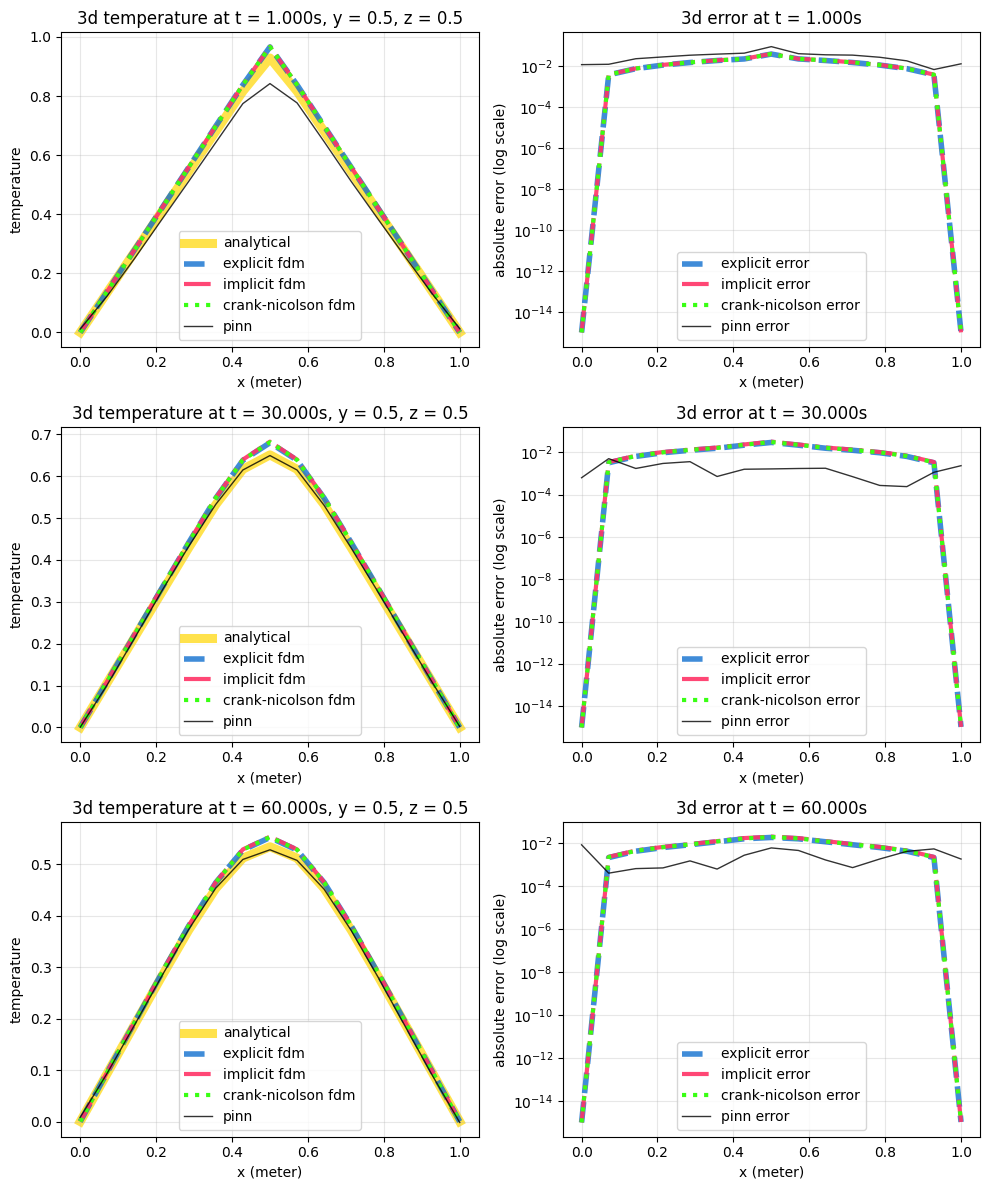

In [58]:
# cell 57: 3d heat equation cross-sectional plots of solution and error
times_3d = get_selected_times(df_analytical_3d, target_times)
plot_dimension('3d', df_analytical_3d, fdm_split['3d'], pinn_solutions['3d'], times_3d, cross_sections={'y': 0.5, 'z': 0.5})


1d collocation points:


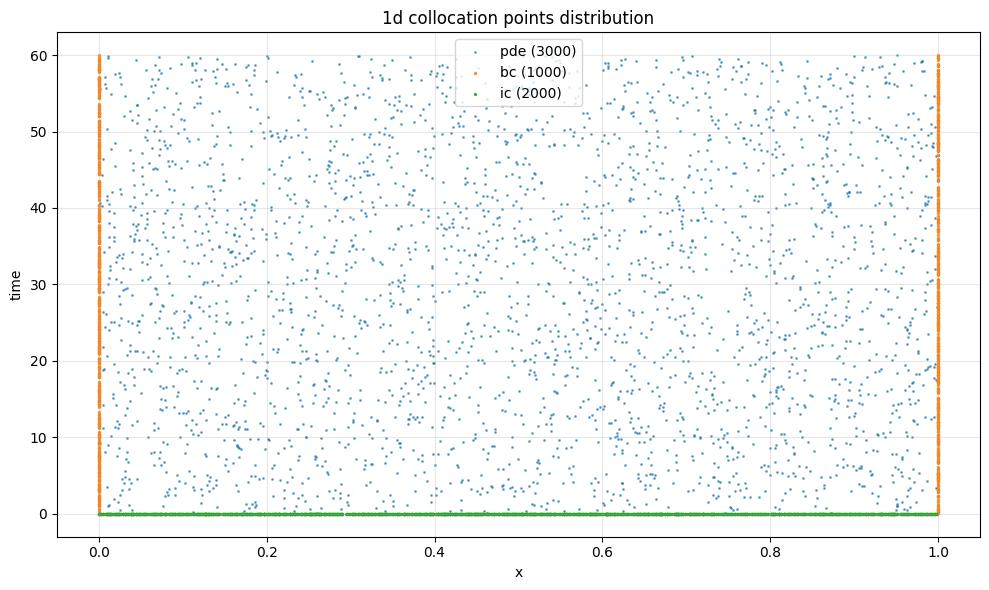


2d collocation points:


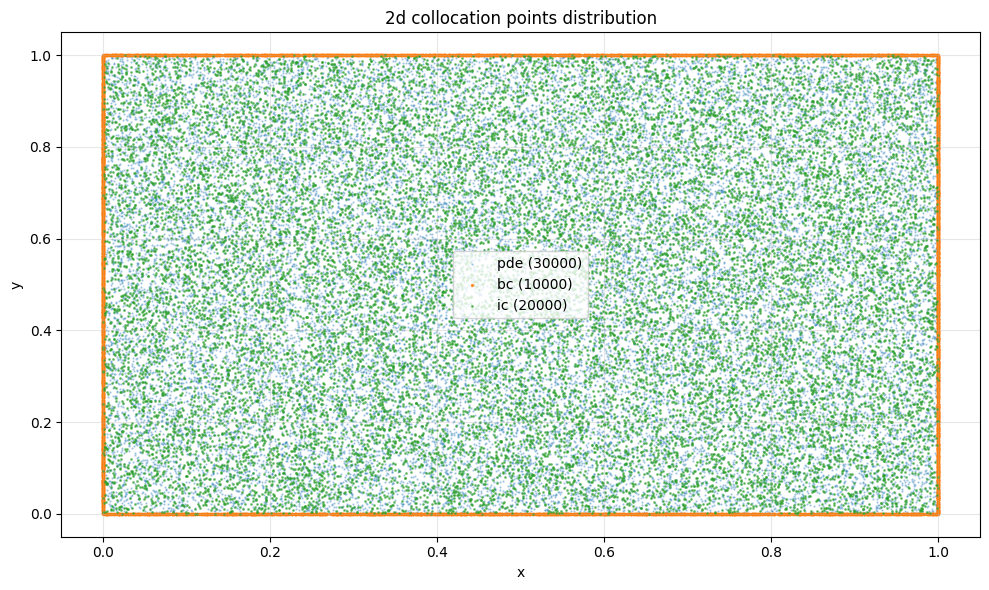


3d collocation points:


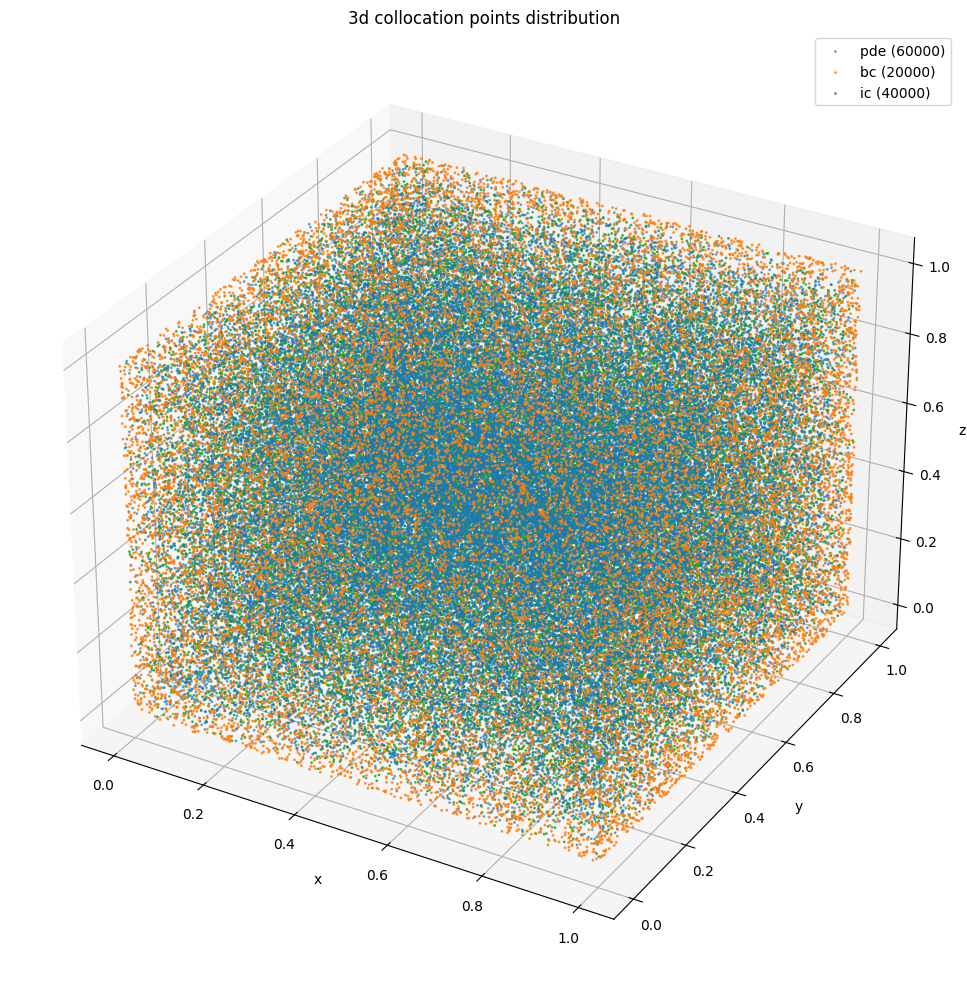

In [59]:
# cell 58: collocation points visualization
def visualize_collocation_points(dim):
    np.random.seed(42)
    sampling = {
        '1d': {'N_pde': 3000, 'N_bc': 1000, 'N_ic': 2000},
        '2d': {'N_pde': 30000,  'N_bc': 10000,   'N_ic': 20000},
        '3d': {'N_pde': 60000, 'N_bc': 20000,  'N_ic': 40000},
    }[dim]

    if dim == '1d':
        fig, ax = plt.subplots(figsize=(10, 6))

        x_pde = np.random.uniform(0, L, sampling['N_pde'])
        t_pde = np.random.uniform(0, t_final, sampling['N_pde'])

        t_bc = np.random.uniform(0, t_final, sampling['N_bc'])
        x_bc = np.concatenate([np.zeros(sampling['N_bc'] // 2),
                               np.full(sampling['N_bc'] // 2, L)])

        x_ic = np.random.uniform(0, L, sampling['N_ic'])
        t_ic = np.zeros(sampling['N_ic'])

        ax.scatter(x_pde, t_pde, s=1, alpha=0.6, label=f'pde ({sampling["N_pde"]})')
        ax.scatter(x_bc, t_bc, s=2, alpha=0.8, label=f'bc ({sampling["N_bc"]})')
        ax.scatter(x_ic, t_ic, s=2, alpha=0.8, label=f'ic ({sampling["N_ic"]})')

        ax.set_xlabel('x')
        ax.set_ylabel('time')

    elif dim == '2d':
        fig, ax = plt.subplots(figsize=(10, 6))

        x_pde = np.random.uniform(0, L, sampling['N_pde'])
        y_pde = np.random.uniform(0, L, sampling['N_pde'])

        n = sampling['N_bc'] // 4
        x_bc = np.concatenate([np.zeros(n), np.full(n, L),
                               np.random.uniform(0, L, n),
                               np.random.uniform(0, L, n)])
        y_bc = np.concatenate([np.random.uniform(0, L, n),
                               np.random.uniform(0, L, n),
                               np.zeros(n), np.full(n, L)])

        x_ic = np.random.uniform(0, L, sampling['N_ic'])
        y_ic = np.random.uniform(0, L, sampling['N_ic'])

        ax.scatter(x_pde, y_pde, s=0.5, alpha=0.3, label=f'pde ({sampling["N_pde"]})')
        ax.scatter(x_bc, y_bc, s=2,   alpha=0.8, label=f'bc ({sampling["N_bc"]})')
        ax.scatter(x_ic, y_ic, s=1,   alpha=0.6, label=f'ic ({sampling["N_ic"]})')

        ax.set_xlabel('x')
        ax.set_ylabel('y')

    else: # 3d
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection='3d')

        x_pde = np.random.uniform(0, L, sampling['N_pde'])
        y_pde = np.random.uniform(0, L, sampling['N_pde'])
        z_pde = np.random.uniform(0, L, sampling['N_pde'])

        n = sampling['N_bc'] // 6
        x_bc = np.concatenate([np.zeros(n), np.full(n, L),
                               np.random.uniform(0, L, 4 * n)])
        y_bc = np.concatenate([np.random.uniform(0, L, 2 * n),
                               np.zeros(n), np.full(n, L),
                               np.random.uniform(0, L, 2 * n)])
        z_bc = np.concatenate([np.random.uniform(0, L, 4 * n),
                               np.zeros(n), np.full(n, L)])

        x_ic = np.random.uniform(0, L, sampling['N_ic'])
        y_ic = np.random.uniform(0, L, sampling['N_ic'])
        z_ic = np.random.uniform(0, L, sampling['N_ic'])

        ax.scatter(x_pde, y_pde, z_pde, s=1, alpha=0.6, label=f'pde ({sampling["N_pde"]})')
        ax.scatter(x_bc, y_bc, z_bc, s=1, alpha=0.8, label=f'bc ({sampling["N_bc"]})')
        ax.scatter(x_ic, y_ic, z_ic, s=1, alpha=0.8, label=f'ic ({sampling["N_ic"]})')

        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('z')

    ax.set_title(f'{dim} collocation points distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{dim}_collocation.png', dpi=300, bbox_inches='tight')
    plt.show()

for dim in ['1d', '2d', '3d']:
    print(f'\n{dim} collocation points:')
    visualize_collocation_points(dim)

In [60]:
# cell 59: calculate grid vs collocation point ratios
point_comparison_results = []

for dim in ['1d', '2d', '3d']:
    # calculate total fdm spacetime nodes
    # formula: (spatial_points^dimension) * time_steps 
    total_fdm_nodes = (Nx ** int(dim[0])) * n_steps
    
    # calculate total pinn collocation budget from tuner
    sampling = tuner.get_adaptive_sampling(dim)
    total_pinn_samples = sampling['N_pde'] + sampling['N_bc'] + sampling['N_ic']
    
    # calculate efficiency ratio (fdm nodes per pinn sample)
    efficiency_ratio = total_fdm_nodes / total_pinn_samples
    
    point_comparison_results.append({
        'dimension': dim,
        'fdm_spacetime_nodes': total_fdm_nodes,
        'pinn_collocation_samples': total_pinn_samples,
        'efficiency_multiplier': efficiency_ratio
    })

df_point_complexity = pd.DataFrame(point_comparison_results)
display(df_point_complexity)

,dimension,fdm_spacetime_nodes,pinn_collocation_samples,efficiency_multiplier
0,1d,1500,6000,0.2500
1,2d,22500,60000,0.3750
2,3d,337500,120000,2.8125


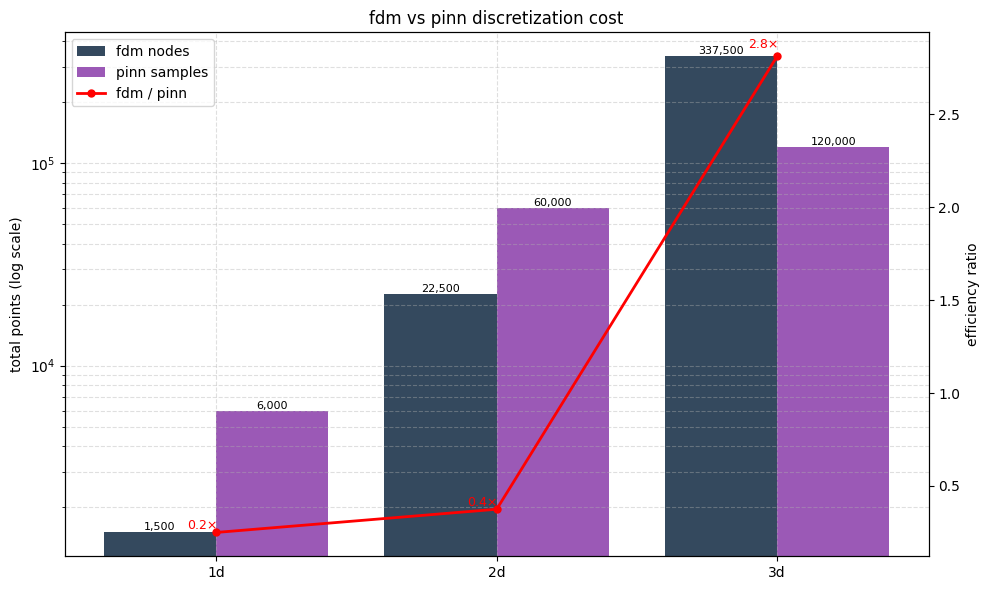

In [61]:
# cell 60: visualize discretization efficiency
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(df_point_complexity))
labels = df_point_complexity['dimension']
width = 0.4

bars_fdm = ax.bar(
    x - width / 2,
    df_point_complexity['fdm_spacetime_nodes'],
    width,
    label='fdm nodes', color='#34495e'
)
bars_pinn = ax.bar(
    x + width / 2,
    df_point_complexity['pinn_collocation_samples'],
    width,
    label='pinn samples', color='#9b59b6'
)

ax.set_yscale('log')
ax.set_ylabel('total points (log scale)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('fdm vs pinn discretization cost')

# bar value labels
for bars in (bars_fdm, bars_pinn):
    for b in bars:
        ax.text(
            b.get_x() + b.get_width() / 2,
            b.get_height(),
            f'{int(b.get_height()):,}',
            ha='center',
            va='bottom',
            fontsize=8,
        )

# efficiency ratio
ax_eff = ax.twinx()
ax_eff.plot(
    x,
    df_point_complexity['efficiency_multiplier'],
    color='red',
    marker='o',
    markersize=5,
    linewidth=2,
    label='fdm / pinn',
)
ax_eff.set_ylabel('efficiency ratio')

for i, r in enumerate(df_point_complexity['efficiency_multiplier']):
    ax_eff.text(i - 0.05, r * 1.01, f'{r:.1f}×', ha='center', va='bottom', fontsize=9, color='red')

# legend and grid
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_eff.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper left')

ax.grid(True, which='both', linestyle='--', alpha=0.4)
fig.tight_layout()
plt.show()